# Classification
**PyCaretでの2値分類予測**
- サンプル事例の背景
  - あるカフェチェーン。都心近郊に10店舗を展開、1万人規模の自社アプリ会員を持つ。
  - アプリ会員はお店での注文時は必ずアプリを提示する。来店せずともアプリを閲覧することはある。
  - だがこれらのデータは現状は有効に活用されていない。
- 問題の設定
  - **誰がラテを購入するかを予測**する（来店した顧客が、ラテを購入する確率、可能性を数値化する）。
  - 結果をどう使うかは詳細未定。まずは、予測が可能なのか、どの程度の精度が出るのを見極めるという初期段階。
  - 施策案: 店頭やアプリでの情報表示などをパーソナライズ、ラテを購入しやすい顧客層の分析、新商品企画やCRMのための顧客理解など。
- 本コードの位置付け
    1. まずは、LightGBMで素早く初動回答することで、関係者合意を取り付けやすい土壌整備を支援する。
    1. 予測結果や反応を受けて、**AutoML（例えばPyCaret）で**、どの系統のアルゴリズムと相性がよさそうかみてみる。
    1. あるいはさらにチューニングしたり、解釈しやすいアルゴリズムを試したり、他のアルゴリズムも試してみるなど。
- PyCaretの特性
  - さまざまな機械学習アルゴリズムを統一的に扱えるAutoMLライブラリ。前処理、モデル選定、ハイパラチューニングなど一気におこなえる。

In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# import scipy
import sklearn
import shap
import pycaret

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas","numpy","matplotlib","seaborn",
"scikit-learn","shap","pycaret",
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-09-11 10:32:10
Python 3.10.20
OS macOS-26.6.2-arm64-arm-64bit
is_google_colab: False
pandas 1.5.3
numpy 1.23.5
matplotlib 3.7.4
seaborn 0.12.2
scikit-learn 1.2.2
shap 0.49.1
pycaret 3.0.4


In [2]:
# サンプルデータの生成（意図的にデータ汚損している）
import string

def generate_cafe_raw_data(n_customers=10000, n_stores=10, seed=42):
    """
    顧客単位×日次のTransaction（アプリのPVや来店）に、顧客マスターや店舗マスターをLeft Joinして生成するイメージ
    - 配下10店舗それぞれの過去3ヶ月の、顧客別ラテ注文有無実績+関連データ
    - 予測には役立ちそうもない特徴量も含まれている
    """
    np.random.seed(seed)
    
    # 共通の期間設定 (計91日間)
    start_date = pd.Timestamp('2025-09-01')
    end_date = pd.Timestamp('2025-11-30')
    date_range = pd.date_range(start_date, end_date)
    holidays = [pd.Timestamp(h) for h in ['2025-09-15', '2025-09-23', '2025-10-13', '2025-11-03', '2025-11-23', '2025-11-24']]  # 祝日リスト
    
    # IDなどの基本パーツ
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    chars = list(string.ascii_lowercase + string.digits)
    customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
    # =================================================================
    # テーブル1: 【顧客マスター (dim_customers)】
    # =================================================================
    # 顧客マスタ（入会日 signup_date を過去3年の範囲でランダム生成）
    # 今回ログの最終日から最大1000日前までの間で入会日を決める
    # これにより、この3ヶ月の期間中に新規入会する（生まれる）顧客も自然にシミュレートできる
    random_days_ago = np.random.randint(0, 1000, n_customers)
    # 入会からの経過日数（tenure）が長い人ほど、飽きてアプリを開かない確率（デバフ）を作る
    # 新規入会者はアクティブ（確率高）、1年以上前の人は幽霊部員になりやすい構造にする

    # 基本のアプリ大好き度
    app_engagement_base = np.random.beta(5, 2, n_customers)
    # 入会からの日数による減衰（半年〜1年でガクッと落ちる）
    tenure_decay = np.exp(-random_days_ago / 365)
    # 最低でも2%は開く
    app_open_prob = (app_engagement_base * tenure_decay).clip(0.02, 1.0)
    
    base_visit_freq_smooth = np.random.gamma(shape=3.0, scale=1.0, size=n_customers).clip(0.5, 15.0)
    
    # ユーザー単位で「金の卵」となるユーザーを定義
    # 入会1年未満（365日未満）のライトユーザーから、ランダムに10%を抽出
    is_light_user = random_days_ago < 365
    is_gold_egg_user = is_light_user & (np.random.rand(n_customers) < 0.10)
    
    df_customers_master = pd.DataFrame({
        'customer_id': customer_ids,
        'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
        'main_store_id': np.random.choice(store_ids, n_customers),  # その人のマイ店舗
        'base_latte_preference': np.random.beta(1.5, 5, n_customers),
        'base_visit_freq': base_visit_freq_smooth, 
        'app_open_prob': app_open_prob,
        'is_gold_egg': is_gold_egg_user.astype(int)  # 内部フラグとしてマスタに追加
    })
    
    # =================================================================
    # テーブル2: 【店舗×日付マスター】 1店舗×1日1行
    # =================================================================
    store_date_records = []
    for s in store_ids:
        for d in date_range:
            store_date_records.append({
                'store_id': s,
                'date': d,
                'is_raining': np.random.binomial(1, 0.2),  # 確率20%で雨
                'station_congestion_index': np.random.normal(100, 15),
                'daily_staffing_cost': int(np.random.randint(50000, 150000))
            })
    df_store_master = pd.DataFrame(store_date_records)
    store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}  # 店舗バイアス
    
    # =================================================================
    # テーブル3: 【日次アプリログ（ベースデータフレーム）】
    # =================================================================
    df_date_base = pd.DataFrame({'date': date_range})
    df_date_base['is_weekend'] = df_date_base['date'].dt.dayofweek.isin([5, 6]).astype(int)
    df_date_base['is_holiday'] = df_date_base['date'].isin(holidays).astype(int)
    df_date_base['is_day_off'] = ((df_date_base['is_weekend'] == 1) | (df_date_base['is_holiday'] == 1)).astype(int)
    
    # 自然な連続値としての気温を作る
    # 9月、10月、11月のベースを滑らかに繋ぎつつ、前日の気温をベースにランダムウォークさせるにゃん
    temps = []
    current_t = 24.0 # 初期値（9月1日の気温ベース）
    for d in date_range:
        # 月ごとの目標となる平均気温
        target_m = 24.0 if d.month == 9 else (17.0 if d.month == 10 else 12.0)
        # 前日の気温を引きずりつつ、今月の目標気温に少し引っ張られつつ、ランダムに変動（±1度程度）
        current_t = current_t * 0.8 + target_m * 0.2 + np.random.normal(0, 1.2)
        temps.append(current_t)
        
    df_date_base['current_temp'] = temps
    
    # クロスジョインで全顧客×全日付のログ枠を生成
    df_cust_stub = pd.DataFrame({'customer_id': customer_ids})
    df_cust_stub['key'], df_date_base['key'] = 1, 1
    df_transaction = pd.merge(df_cust_stub, df_date_base, on='key').drop('key', axis=1)
    
    # STEP1: トランザクションに顧客マスターをLeft Join（SQLのイメージ）
    df_log = pd.merge(df_transaction, df_customers_master, on='customer_id', how='left')
    
    # 入会前のレコードをカット＆会員日数の計算
    df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
    df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
    # 現実化フィルター
    # 各ユーザー×各日付に対してサイコロを振り、その日の起動確率を下回った日は「行ごと消滅」させる
    # ただし、当日お店に行く日（後述のvisit_logitが上振れる日）のログが消えるとバグるので、
    # お店に行く、またはアプリを自主的に開いた日だけを生存させるロジックにする
    visit_logit_temp = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_prob_temp = 1 / (1 + np.exp(-visit_logit_temp))
    
    # お店に行く確率かアプリを開く確率のどちらかで生存判定
    survival_prob = np.maximum(visit_prob_temp, df_log['app_open_prob'])
    df_log = df_log[np.random.rand(len(df_log)) < survival_prob].reset_index(drop=True)
    
    # フラグ決定フェーズ（行が間引かれた状態で実行される）
    # STEP2: 確率計算をして、日々の行動フラグ（来店・PV・購買）を決定
    # (※確率計算のために、一時的にその日の雨フラグだけ裏で店舗マスタから貰ってくる)
    df_log = pd.merge(df_log, df_store_master[['store_id', 'date', 'is_raining']], 
                      left_on=['main_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('store_id', axis=1)
    
    # 顧客マスタから引き継いだフラグをそのままマスクとして使用
    gold_egg_mask = df_log['is_gold_egg'] == 1
    
    # ① 来店フラグ (is_visited)
    visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
    df_log['is_visited'] = np.random.binomial(1, 1 / (1 + np.exp(-visit_logit)))
    
    # ② アプリPV数 (app_pv)
    # お店に行かない日は、PV数が0や1の日が大量に発生するようにポアソン分布を調整
    base_pv = np.random.poisson(0.5, len(df_log)) + df_log['is_visited'] * 4
    df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(3, len(df_log)), base_pv)
    # 最低でもアプリの起動ログがある以上、1PVは発生させる
    df_log['app_pv'] = df_log['app_pv'].clip(lower=1)
    
    # ③ ラテ購入フラグ (is_purchased)※条件付き確率
    # 雨の日は確率が下がる
    store_bias = df_log['main_store_id'].map(store_effect)
    purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
    purchase_logit = np.where(df_log['is_raining'] == 1, purchase_logit - 1.5, purchase_logit)
    purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
    df_log['is_purchased'] = np.random.binomial(1, 1 / (1 + np.exp(-purchase_logit))) * df_log['is_visited']
    
    # 内部用の不要カラムを落とす
    # 一時的に使った雨フラグと、不要になった顧客マスタの感度用内部カラム（金の卵フラグ含む）を落とす
    df_log = df_log.drop(['is_raining', 'base_latte_preference', 'base_visit_freq', 'app_open_prob', 'is_gold_egg'], axis=1)
    
    # STEP3: 来店キーの作成
    # 来店してない日は NaN になるので、店舗マスタと結合できずにNull出力になる仕組み
    df_log['join_store_id'] = np.where(df_log['is_visited'] == 1, df_log['main_store_id'], np.nan)
    df_log = df_log.drop('main_store_id', axis=1)  # マイ店舗の漏洩を防ぐ
    
    # STEP4: トランザクションに店舗×日付マスターをLeft Join
    df_final = pd.merge(df_log, df_store_master, left_on=['join_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('join_store_id', axis=1)
    
    # カラムの並び順を整理
    df_dirty = df_final[[
        'date', 'customer_id', 'membership_days', 'app_pv', 'store_id', 'is_visited', 'is_purchased',  'current_temp', 'is_raining', 'station_congestion_index', 'daily_staffing_cost']]
        
    # 意図的にデータ汚損
    df_dirty = df_dirty.copy()
    # わざと欠損値を含める
    df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    # わざとobject型にする
    df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
    # わざと?を混入させる
    df_dirty.loc[df_dirty.sample(frac=0.005).index, 'membership_days'] = '?'
    # 空文字トラップ
    df_dirty.loc[df_dirty.sample(frac=0.003).index, 'membership_days'] = ''
    df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
    # アプリPV（app_pv）の1%をNaNにする
    df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
    # 店舗ID（store_id）の一部（0.5%）を小文字混じりにする
    valid_store_idx = df_dirty[df_dirty['store_id'].notnull()].sample(frac=0.005).index
    df_dirty.loc[valid_store_idx, 'store_id'] = df_dirty.loc[valid_store_idx, 'store_id'].str.lower()
    
    # 時系列のシャッフル（未ソートで出力）
    df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)

    print(f"データセット生成完了！ 総行数: {len(df_dirty)}行")
    return df_dirty

# 実行
df1 = generate_cafe_raw_data()

データセット生成完了！ 総行数: 226445行


データセットの内容（カラムの説明）
- date ログデータ発生日（アプリ利用日: 来店してのアプリ提示も含む）
- customer_id 顧客ID
- membership_days アプリ会員になってからの経過日数
- app_pv アプリ閲覧数
- store_id 店舗ID
- is_visited 来店有無
- is_purchased ラテ購入有無
- current_temp その日の気温
- is_raining 降雨フラグ
- station_congestion_index 店舗の最寄駅の混雑指数
- daily_staffing_cost その日のそのお店のパート、バイト人件費総額

すでにわかっていること
- 目的変数: **is_purchased** ラテ購入有無
- アプリ会員はお店での注文時は必ずアプリを提示する。来店せずともアプリを閲覧することはある。
- データセットは、顧客単位×日次のTransaction（アプリのPVや来店）に、顧客マスター情報や店舗マスター情報が紐づいた内容。
- 簡易的なアプリのため、アプリログの詳細や顧客属性情報（年齢や性別など）はない。

とりあえずの方針
- 顧客の状態を表す特徴量が豊富ではないため、時系列データをうまく使って、特徴量を増やす必要ありそう。

# Speedy Check
- データセットの中身や時点データの推移など、ある程度はすでに見ている前提
- ここでは読み込んだデータセットの中身をざっと確認する

In [3]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

        date customer_id membership_days  app_pv store_id  is_visited  \
0 2025-10-25    zr9fk3nj             867     1.0      NaN           0   
1 2025-10-07    4zck20j8             426     5.0  Store_D           1   
2 2025-09-08    bu6lvy01              27     1.0      NaN           0   
3 2025-09-13    e6x7yyve              14     1.0      NaN           0   
4 2025-11-05    y8abopw8              15     1.0      NaN           0   

   is_purchased  current_temp  is_raining  station_congestion_index  \
0             0     15.792930         NaN                       NaN   
1             0     18.477874         0.0                 81.960862   
2             0     23.322725         NaN                       NaN   
3             0     23.180668         NaN                       NaN   
4             0     13.955347         NaN                       NaN   

   daily_staffing_cost  
0                  NaN  
1             121841.0  
2                  NaN  
3                  NaN  
4        

In [4]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
# 期待してるデータ型になってそうか？nullがありそうか？（次のdescribeでも把握可能）
print(df1.info())

(226445, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   date                      226445 non-null  datetime64[ns]
 1   customer_id               226445 non-null  object        
 2   membership_days           226445 non-null  object        
 3   app_pv                    224181 non-null  float64       
 4   store_id                  38307 non-null   object        
 5   is_visited                226445 non-null  int64         
 6   is_purchased              226445 non-null  int64         
 7   current_temp              219652 non-null  float64       
 8   is_raining                38307 non-null   float64       
 9   station_congestion_index  38307 non-null   float64       
 10  daily_staffing_cost       38307 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(3

In [5]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 数値型カラムの要約統計量
df1.describe(include='number').round(2)

# is_visited, is_purchased, is_rainingは2値っぽい
# 他カラムについてはこれだけではよくわからない（極端な外れ値は含まれてるのかもだし、妥当な範囲かもしれない）

,app_pv,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost
count,224181.00,226445.00,226445.00,219652.00,38307.0,38307.00,38307.00
mean,1.87,0.17,0.05,17.85,0.2,101.35,98874.56
std,2.09,0.37,0.22,4.31,0.4,15.29,28314.08
min,1.00,0.00,0.00,8.26,0.0,41.81,50181.00
25%,1.00,0.00,0.00,13.97,0.0,91.03,74292.00
50%,1.00,0.00,0.00,18.43,0.0,101.32,98798.00
75%,2.00,0.00,0.00,21.40,0.0,111.53,122543.00
max,31.00,1.00,1.00,25.50,1.0,154.92,149992.00


In [6]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 非数値型カラムの要約統計量（datetime型なら期間の範囲、文字列ならばユニーク値や頻出値かなど）
df1.describe(exclude='number')

# dateカラムはdatetime型になってる。範囲はわかる（でも毎日分あるかは不明）
# customer_idとstore_idは文字列扱いなので情報少ない（ユニーク値や頻出値が妥当なのかはよくわからない）

,date,customer_id,membership_days,store_id
count,226445,226445,226445,38307
unique,91,9994,1002,20
top,2025-11-30 00:00:00,eqh7iw8g,?,Store_J
freq,3167,75,1129,4136
first,2025-09-01 00:00:00,NaN,NaN,NaN
last,2025-11-30 00:00:00,NaN,NaN,NaN


membership_daysはカラム名からすると数値型っぽいがそうなってないこと。数値以外のデータが混じってるらしいことがわかる

1. PyCaretや主要な機械学習ライブラリでは、NaNがあっても対処可能
1. だが、NaNではない欠損値（例えば空文字や不正な値）が混じっている場合はモデル作成時にエラーとなる
1. よって手軽に素早くモデル作成したい場合は、ひとまず欠損値をNaNにしてしまう
1. NaNを補完（例えば平均値や中央値で埋めるなど）するかどうかは別として、とりあえずNaNにしておけば先に進める

一方で、以下の場合はさほど致命的な事態は招きにくい
- 本来はカテゴリ変数や文字列として扱いたいカラムが、数値型扱いになっている
- カテゴリ変数や文字列として扱いたいカラムに、表記揺れ、空白、全角半角の違いなどが混じっている

これらはモデル性能の低下は招くが、素早くモデルを作成したり、アルゴリズムの選定においては最優先事項でもない

## dtypes exclude number
- 非数値型扱いになっているが、数値として扱いたいカラムが混ざっていないか？のチェック
  - 連続値データだけと思ってたら、?や空文字（スペースだけ）のような文字が混入しているなど
  - エクセルで数値の先頭に'をつけてたり、エクセル書式で文字列設定していた影響が残っているなど

In [7]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226445 entries, 0 to 226444
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             226445 non-null  datetime64[ns]
 1   customer_id      226445 non-null  object        
 2   membership_days  226445 non-null  object        
 3   store_id         38307 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 6.9+ MB


In [8]:
# チェックしたいカラムをリストアップ（文字列扱いカラムのうち、そうであって欲しくないカラムのみ）
# ここでは文字列扱いじゃないカラムもうっかり含めちゃった想定にしている（自作関数のフィルタチェック目的でもある）
target_numeric_cols = ['membership_days', 'app_pv', 'current_temp']

In [9]:
def scan_numeric_columns(df, target_cols):
    """
    数値型であって欲しいカラムをスキャンし、数値以外のデータが混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのカラムだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---")
    total_count = len(df)
    
    for col in check_cols:
        # 1. もともとnullだった数をカウント
        original_nan_count = df[col].isna().sum()
        original_nan_rate = (original_nan_count / total_count) * 100
        
        # 2. 数値に変換を試みる（数値にできないエラーのぶんは強制的にNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # 3. もともとnullではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        # 画面に出力するフェーズ
        print(f"⚠️ {col}")
        print(f"   ∟ 総行数: {total_count:,} 件")
        print(f"   ∟ ① もともとの欠損値(Null)   : {original_nan_count:,} 件 ({original_nan_rate:.2f} %)")
        
        if not non_numeric_rows.empty:
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            trash_rate = (total_non_numeric / total_count) * 100
            
            print(f"   ∟ ② 数値以外のデータ : {total_non_numeric:,} 件 ({trash_rate:.2f} %)")
            print(f"      [詳細内訳]")
            for val, cnt in counts.items():
                # 空文字（長さ0）はわかりにくいので、明示的にテキスト表現する
                display_val = '"" (空文字)' if str(val).strip() == '' else f"'{val}'"
                print(f"         - {display_val}: {cnt:,} 件")
        else:            
            print(f"   ∟ ② 数値以外のデータ : 0 件 (0.00 %) -> 混入物なし！")
            
        print("-" * 45)

In [10]:
scan_numeric_columns(df1, target_numeric_cols)

# membership_daysはカラム名からすると数値型っぽいがそうなってなかったのは、'?'や''が混入してたからと判明
# 混入物が占める割合は多くはない
# だがnullの件と同様に、この混入物がどんな条件のときに発生しているのか（規則性あるか）を見ておく

--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---
⚠️ membership_days
   ∟ 総行数: 226,445 件
   ∟ ① もともとの欠損値(Null)   : 0 件 (0.00 %)
   ∟ ② 数値以外のデータ : 1,808 件 (0.80 %)
      [詳細内訳]
         - '?': 1,129 件
         - "" (空文字): 679 件
---------------------------------------------


In [11]:
def check_trash_impact(df, target_col, metrics_cols):
    """
    数値型であって欲しいカラムを状態別に、数値型カラム（目的変数や主要カラム）の平均値を比較するにゃん。
    """
    # 1. 状態を判定するためのベース（文字列化して前後の空白を削除）
    col_str = df[target_col].astype(str).str.strip()
    
    # 2. 条件分岐用のマスクを作成（ここの定義を増やせば拡張可能。check_nan_impact関数の上位互換）
    is_real_nan = df[target_col].isna()
    is_q_mark = (col_str == '?')
    is_empty = (col_str == '')
    
    # 3. 状態を定義するラベルのSeriesを生成
    # デフォルトを「正常（数値）」にしておき、各条件に合う場所を上書きする
    status_series = pd.Series("0_正常（数値）", index=df.index)
    status_series[is_real_nan] = "1_欠損（NaN）"
    status_series[is_q_mark] = "2_ゴミ（'?'）"
    status_series[is_empty] = "3_ゴミ（空文字）"
    
    # 4. 作成したラベルでgroupbyをかけ、主要指標の平均値を計算
    res = df.groupby(status_series)[metrics_cols].mean().round(4)
    
    # 5. 各状態の件数（行数）をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "count", df.groupby(status_series).size())
    
    print(f"📊 {target_col}")
    return res

In [12]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_trash_impact(df1, "membership_days", ["is_purchased", "is_visited", "app_pv"])

# どうやら混入物の発生に規則性はなさそう
# だがこの自作関数はmeanを計算しているため文字列型カラムなどについては判定不能なことから以下もおこなう（例えば特定のstore_idでのみ混入物が発生している可能性は残る）

📊 membership_days


,count,is_purchased,is_visited,app_pv
0_正常（数値）,224637,0.0487,0.1691,1.8709
2_ゴミ（'?'）,1129,0.0531,0.1771,1.9830
3_ゴミ（空文字）,679,0.0501,0.1723,1.9156


In [13]:
def check_category_trash_impact(df, target_col, cat_col):
    """
    数値型カラムの混入物が、特定のセグメント、カテゴリに集中（偏って）発生していそうかをみるにゃん。
    """
    # 1. 状態のラベルSeriesを作る（ここの定義を増やせば拡張可能）
    col_str = df[target_col].astype(str).str.strip()
    status_series = pd.Series("0_正常", index=df.index)
    status_series[df[target_col].isna()] = "1_欠損（NaN）"
    status_series[col_str == '?'] = "2_ゴミ（'?'）"
    status_series[col_str == ''] = "3_ゴミ（空文字）"
    
    # 2. クロス集計しつつ、行（状態）ごとの比率（normalize='index'）に変換する
    # それぞれの状態における指定セグメントのシェアを計算
    cross_pct = pd.crosstab(status_series, df[cat_col], normalize='index') * 100
    
    print(f'📊 "{target_col}" の混入物における、{cat_col}の構成比（%）')
    
    # 3. 各行（状態）ごとに、シェアが高い上位5つを抽出
    for status in cross_pct.index:
        print(f"\n▶️ 【{status}】での {cat_col}の上位シェア:")
        top5 = cross_pct.loc[status].sort_values(ascending=False).head(5)
        for cat, val in top5.items():
            print(f"   ∟ {cat}: {val:.2f} %")
            
    print("-" * 45)

In [14]:
check_category_trash_impact(df1, "membership_days", "store_id")

# 混入物状態におけるstore_idの出現率に極端な偏りはなさそう、正常データにおける出現率とも似た傾向を示している
# つまり特定のstore_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、store_idの構成比（%）

▶️ 【0_正常】での store_idの上位シェア:
   ∟ Store_J: 10.78 %
   ∟ Store_F: 10.74 %
   ∟ Store_I: 10.22 %
   ∟ Store_E: 10.03 %
   ∟ Store_H: 9.87 %

▶️ 【2_ゴミ（'?'）】での store_idの上位シェア:
   ∟ Store_A: 13.50 %
   ∟ Store_J: 12.50 %
   ∟ Store_G: 12.00 %
   ∟ Store_B: 10.50 %
   ∟ Store_H: 10.00 %

▶️ 【3_ゴミ（空文字）】での store_idの上位シェア:
   ∟ Store_B: 14.53 %
   ∟ Store_H: 13.68 %
   ∟ Store_C: 12.82 %
   ∟ Store_J: 12.82 %
   ∟ Store_E: 11.97 %
---------------------------------------------


In [15]:
check_category_trash_impact(df1, "membership_days", "date")

# 特定の日付でのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、dateの構成比（%）

▶️ 【0_正常】での dateの上位シェア:
   ∟ 2025-11-30 00:00:00: 1.40 %
   ∟ 2025-11-29 00:00:00: 1.37 %
   ∟ 2025-11-22 00:00:00: 1.37 %
   ∟ 2025-11-24 00:00:00: 1.37 %
   ∟ 2025-11-23 00:00:00: 1.35 %

▶️ 【2_ゴミ（'?'）】での dateの上位シェア:
   ∟ 2025-10-05 00:00:00: 2.04 %
   ∟ 2025-11-23 00:00:00: 1.86 %
   ∟ 2025-10-19 00:00:00: 1.59 %
   ∟ 2025-09-14 00:00:00: 1.59 %
   ∟ 2025-09-27 00:00:00: 1.59 %

▶️ 【3_ゴミ（空文字）】での dateの上位シェア:
   ∟ 2025-10-26 00:00:00: 2.36 %
   ∟ 2025-09-14 00:00:00: 2.21 %
   ∟ 2025-11-30 00:00:00: 2.06 %
   ∟ 2025-11-14 00:00:00: 2.06 %
   ∟ 2025-11-06 00:00:00: 1.77 %
---------------------------------------------


In [16]:
check_category_trash_impact(df1, "membership_days", "customer_id")

# 特定のcustomer_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、customer_idの構成比（%）

▶️ 【0_正常】での customer_idの上位シェア:
   ∟ eqh7iw8g: 0.03 %
   ∟ 356f9bg3: 0.03 %
   ∟ wb8nbspy: 0.03 %
   ∟ t2ne0d2c: 0.03 %
   ∟ rslxex03: 0.03 %

▶️ 【2_ゴミ（'?'）】での customer_idの上位シェア:
   ∟ cai4zq7i: 0.27 %
   ∟ lyu9wpn4: 0.27 %
   ∟ 64kqbc75: 0.27 %
   ∟ 4ma68ifi: 0.27 %
   ∟ vqzcghtl: 0.18 %

▶️ 【3_ゴミ（空文字）】での customer_idの上位シェア:
   ∟ g5sbjqlf: 0.29 %
   ∟ 14sz2k5u: 0.29 %
   ∟ 2wcupt8e: 0.29 %
   ∟ mol8hj7h: 0.29 %
   ∟ d15am9zm: 0.29 %
---------------------------------------------


In [17]:
# membership_daysカラムの混入物の発生に規則性はなさそう
# このカラムは数値型であって欲しいので、混入物はなんらかの処理をしておきたい
# 数値以外のデータが少数なことと、素早い初動回答を優先して、NaN（欠損値）に置換する
# NaNにすることが最善手かは不明だが、先に進むためにはいったんキレイに数値型にしておくほうが好都合

# 数値に変換を試みることで、数値にできない混入物は強制的にNaNにできる
df1['membership_days'] = pd.to_numeric(df1['membership_days'], errors='coerce')

In [18]:
# 自作関数でデータフレームのnull率やユニーク数を確認する
# infoやdescribeの補完として、データ構造の把握にも役立つ

def check_null_and_uniques(df, columns=None):
    """
    各カラムのnull率、ユニーク数などを集計するにゃん。
    df: 対象のデータフレーム
    columns: 集計したいカラムのリスト。省略（None）した場合は、すべてのカラムが対象    
    """
    if columns is None:
        target_df = df  # カラム未指定時は全カラムを対象にする
    else:
        if isinstance(columns, str):
            columns = [columns]  # 単一カラム指定時用
            
        # 指定されたカラムの中に、元のdfに存在しないものがないかチェック
        missing_cols = [c for c in columns if c not in df.columns]
        if missing_cols:
            raise ValueError(f"エラー：指定カラム {missing_cols} はそのデータフレームに存在しないにゃん!")
            
        # 指定されたカラムだけに絞り込む
        target_df = df[columns]

    total_rows = len(target_df)
    null_counts = target_df.isnull().sum()
    non_null_counts = total_rows - null_counts
    unique_counts = target_df.nunique()

    report_df = pd.DataFrame({
        'type': target_df.dtypes,                              # データ型
        'total_count': total_rows,                            # 全体の行数（null率の分母）
        'non_null': non_null_counts,                          # 非欠損値の行数
        'null': null_counts,                                  # 欠損値の数
        'null_rate(%)': (null_counts / total_rows * 100),     # 欠損率（%）全体の何％が欠損しているか
        'unique': unique_counts,                              # ユニーク数
        'non_null/unique': non_null_counts / unique_counts   # 頻度（1ユニークあたりの平均行数）
    })

    return report_df.sort_values(by='null', ascending=False).round(2)  # nullの数が多い順でソート

# 実行
check_null_and_uniques(df1)

# 見方の説明
# ・店舗に関連するような特徴量はnullの数と率が同じ。つまり同じような条件でnullになるらしいことがわかる。
# ・全体のレコード数とユニークカウント値との桁数の違いも、データ構造を推し量る材料になる。
# ・例えばdf全体で22万行あるが、dateのユニーク値は91日分。ということは、1つのdateが何度も登場するらしい。
# ・同様にcustomer_idもユニーク値は1万弱なので、同じ顧客が何度も登場するらしい。
# ・22万行あるが、date91日×customer_id1万人=91万件よりは少ないので、全員が毎日登場するわけではないらしい。

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
store_id,object,226445,38307,188138,83.08,20,1915.35
is_raining,float64,226445,38307,188138,83.08,2,19153.50
station_congestion_index,float64,226445,38307,188138,83.08,910,42.10
daily_staffing_cost,float64,226445,38307,188138,83.08,903,42.42
current_temp,float64,226445,219652,6793,3.00,91,2413.76
app_pv,float64,226445,224181,2264,1.00,29,7730.38
membership_days,float64,226445,224637,1808,0.80,1000,224.64
date,datetime64[ns],226445,226445,0,0.00,91,2488.41
customer_id,object,226445,226445,0,0.00,9994,22.66
is_visited,int64,226445,226445,0,0.00,2,113222.50


In [19]:
# store_idを特徴量に使うので、category型にする
# （店舗により購入率が違うという既知情報に従っている）

# nanをなくしてからsortしてunique() を取る
store_order = sorted(df1['store_id'].dropna().unique())

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)
df1['store_id'].unique()

[NaN, 'Store_D', 'Store_J', 'Store_B', 'Store_I', ..., 'store_d', 'store_a', 'store_g', 'store_b', 'store_c']
Length: 21
Categories (20, object): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'store_g' < 'store_h' < 'store_i' < 'store_j']

# Time Series
- 時系列データであることを活かして特徴量を新規追加する

In [20]:
# 日付型のカラムから特徴量を作成
# 特徴量として使えるように数値型に分解する（必要に応じてカテゴリ型に変換する）

# df1['year']        = df1['date'].dt.year          # 年（2025など）
# df1['month']       = df1['date'].dt.month         # 月（1～12）
# df1['day']         = df1['date'].dt.day           # 日（1～31）
# df1['hour']        = df1['date'].dt.hour          # 時間（0～23）朝と昼の違い

df1['day_of_week_num'] = df1['date'].dt.dayofweek     # 曜日フラグ（0:月, 1:火 ... 6:日）
# df1['is_weekend']  = df1['date'].dt.dayofweek >= 5 # 週末フラグ（True/False）
df1['is_weekend'] = df1['date'].dt.dayofweek.isin([5, 6]).astype(int)  # 土日フラグ（5:土曜日, 6:日曜日）

day_of_week_num
0    0.0499
1    0.0293
2    0.0257
3    0.0260
4    0.0281
5    0.0857
6    0.0804
Name: is_purchased, dtype: float64


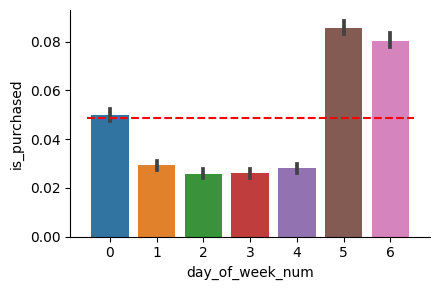

In [21]:
# 曜日別の購入率を見てみる
print(df1.groupby('day_of_week_num')['is_purchased'].mean().round(4))


# グラフで確認
sns.catplot(data=df1, x="day_of_week_num", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['day_of_week_num'].unique()))
plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['day_of_week_num'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
# plt.xticks(rotation=90)
plt.show()

# 土日は購入率高い（なので土日フラグという特徴量を作るのがよさそう）
# 平日のうち月曜だけなんか高い。他の曜日はほぼ同じ。月曜はひょっとしたら祝日発生しやすいぶんで高くなってる可能性あるかも

In [22]:
# データセットの期間内の祝日をみてみる

import jpholiday
start, end = df1['date'].min(), df1['date'].max()  # df['ds'] から期間の開始日と終了日を取得
years = df1['date'].dt.year.unique()  # 年をまたぐ可能性考えて、ユニークな年を取得

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name, 'day_of_week': pd.to_datetime(date).dayofweek, 'day_of_week_en': pd.to_datetime(date).strftime('%a')})
holidays_df = pd.DataFrame(holidays_list)
holidays_df

# 期間内の祝日6日間のうち月曜は4日だった

,ds,holiday,day_of_week,day_of_week_en
0,2025-09-15,敬老の日,0,Mon
1,2025-09-23,秋分の日,1,Tue
2,2025-10-13,スポーツの日,0,Mon
3,2025-11-03,文化の日,0,Mon
4,2025-11-23,勤労感謝の日,6,Sun
5,2025-11-24,勤労感謝の日 振替休日,0,Mon


In [23]:
# 祝日フラグの特徴量を作成する
df1['is_holiday'] = df1['date'].isin(holidays_df['ds']).astype(int)

# Check y
目的変数の特徴をつかむ

- 不均衡チェック: 大量データでもis_purchased=1（購入者）が少数になっていないか
  1. ベースラインの把握: ラテ購入率（陽性率）の規模感次第でモデルでの改善目標も違ってくる
  1. 評価指標の判断: 購入率が極端に不均衡の場合はROC-AUCよりもPR-AUC
  1. 不均衡だった場合の対策検討: 前処理やモデルの学習方法
  1. 特徴量エンジニアリングの方向性把握: 購入率が極端に低い場合、平穏な特徴量だけではモデルが学習しきれないかも

- 特徴量との相関: 特徴量の選択やモデル解釈に
  - 目的変数と特徴量との相関をざっとみておく
  - 特徴量同士の相関もざっとみておく

In [24]:
# 目的変数（is_purchased）の内訳をみる

target = df1['is_purchased']

pd.DataFrame({
    'count': target.value_counts(dropna=False),
    'ratio(%)': target.value_counts(normalize=True, dropna=False) * 100
}).round(2)

# 目的変数（ラテ購入率）は観測データ全体のうち4%
# なのでこのデータセットにおける目的変数は、極端な不均衡データといえそう
# つまりROC-AUCよりもPR-AUCでモデル評価するのがよさそうだし、予測精度向上には強力な特徴量が欲しくなる

,count,ratio(%)
0,215402,95.12
1,11043,4.88


In [25]:
# # 来店しない時は購入しようがない（is_visited=0ならis_purchased=0になっている）のは既知なんだが、改めて確認するならこう
# pd.crosstab(df1['is_purchased'], df1['is_visited'])

In [26]:
# 目的変数（is_purchased）の内訳をみる（来店者ベース）

target = df1.query('is_visited == 1')['is_purchased']

pd.DataFrame({
    'count': target.value_counts(),
    'ratio(%)': target.value_counts(normalize=True) * 100
}).round(2)

# 来店者のみであれば、ラテ購入率は28%なので、極端に不均衡というわけでもなさそう

,count,ratio(%)
0,27264,71.17
1,11043,28.83


**方針検討**
- 購入有無(y: is_purchased)と来店有無(is_visited)には強い関係性がある。
- であれば、目的変数は以下2つに分解して捉えるとよさそう。
  - 来店するかどうか要因: どうやって店舗に足を運んでもらえるか（来店有無という行動履歴以外に、曜日、天気、気温など）
  - 来店したうえで購入するかどうか要因: 顧客自身の特性（購入意欲のようなもの、よくラテを飲む、ラテが好きかなど）
- P(購入)= P(来店) × P(購入∣来店) 
  - P(来店) ＝ ログが存在する日に来店する確率（is_visited=1の行数 / データセット全体の行数）
  - P(購入∣来店) ＝ 来店という条件のもとで、購入する確率（分母はis_visited=1の行数）
  - モデルで予測したい「未来のある日の購入確率」は、2つの確率の掛け算（条件付き確率）
- 前者については、is_visitedを筆頭にすでにいくつかの特徴量がある。
- 後者について、顧客ごとの特性を表す特徴量を追加することで、予測に有用な情報を加えられる可能性がある。

であれば、後者の特徴量は、is_visited=1をベースにした指標が適していそう。
- is_visited=0コミだと購入率4%と不均衡なため、来店有無による顧客の違いが、顧客ごとの特性を表す指標に反映されにくくなる。
- 例えば過去の購入率を特徴量とする場合、来店しなかった日も分母に含めると、購入率は全体として低い値に寄りやすい。
- そこで、来店した日を分母とした過去の購入率であれば、「来店したときに購入しやすいか」という**顧客特性をより直接的に**表現できる。
- このように、予測したい事象に対応した指標を特徴量として作成することで、モデルが利用しやすい情報になることが期待できる。

ちなみに、
- データセット全体では is_purchased=1（陽性率）は4%と不均衡で、かつ is_visited=0 のときは必ず is_purchased=0 となる。
- そのため、is_visitedをそのまま特徴量に入れると、モデルは「is_visited=0 なら is_purchased=0」という関係を強く利用する可能性がある。
- これは期待しているモデルではない。それに当日の来店有無で予測するのは目的変数をカンニングしてる状態でもある。
- いずれにしろ、is_visitedは特徴量として使えない。

**対処案**
1. 来店者のみでモデル作成する
    - is_visited=1のデータだけでモデルを作成する
    - シンプルでわかりやすい、素早く実行しやすい、ビジネス目的にも一致しており理解も得やすい（制御しにくい来店させるためのアクションは留保のうえ、来店した場合の分類予測に特化しやすい）
1. 2段階モデルを組む
    - 1段階目: 全ユーザーを対象に来店予測モデルAを作成、2段階目: 来店した場合の購入予測モデルBを作成する
    - 最終的な予測値（最終スコア）は、モデルAの予測確率 × モデルBの予測確率］ という掛け算で算出する。
    - 来店するかどうか含めて全ユーザーの購入確率を予測したい場合に適している。
    - 各モデルがそれぞれのタスクに集中できる一方、モデルが2つになるため、構築・評価・運用はより複雑になる。
1. 当日のis_visitedを「過去の行動履歴」に置き換える
    - 例えば過去にたくさん来店している人は購入しやすそう、などの発想からis_visitedに代わる特徴量を用意する。
    - 例えば過去一定期間の来店日数、来店率、購入日数、購入率など
    - 時点データならではの特徴を活かしつつ、当日来店してない→当日購入はしない、という因果を打ち消せる。
    - この場合、1同様に来店者のみモデルとすることもできるし、全ユーザー対象のモデルとすることもできる。
    - 後者の場合は購入率4%という極端な不均衡の影響を考慮する必要があり、モデルの評価や特徴量設計が難しくなる可能性がある。

**方針**
- 来店者のみでモデル作成する
- is_visitedは使わない（使えない）
- 過去の行動履歴をもとに、特徴量を新規作成、追加する

# Add Customer Feature
- 過去の行動履歴をもとに、**顧客特性を表しそうな特徴量**を作成する
- 時系列データでの顧客特性を表す区分は主に5つの切り口が考えられる

1. Total（累積）
    - 期間計での累積（expanding）
    - 各顧客のベースラインやポテンシャルを把握（Heavy/Medium/Light, 既存/復活/新規）
    - 例: 期間計でのapp_pv発生日数を顧客単位で集計
2. State（状態）
    - 一定期間での推移（rolling）
    - 顧客状態の「緩やかな」変動を把握（そのときどきでのコンディションを中期的、連続的な視点で捉える）
    - 例: 前日までの直近7日間のapp_pvの移動平均
3. Lag（鮮度）
    - 直近の情報（lag）
    - 古い情報よりも「新鮮な」情報を重点的に把握（Recencyを点で捉える）
    - 例: 1日前や3日前のapp_pv
4. Momentum（勢い）
    - スパイク、変化の差分や比率（diff, ratio）
    - 顧客状態の「急激な」変化を把握（短期的、瞬発的な視点で捉える）
    - 例: 3日前のapp_pv - 7日前のapp_pv（差分あるいは割って比率にする。StateやLagから算出）
5. Interval（間隔）
   - 行動をしていない空白期間（interval）
   - 「定着度合い」や習慣、リズムを把握（Recencyを線で捉える）
   - 例: 最後のapp_pv発生日からの経過日数（短いほど定着してそう、間が空くほど離脱リスクありそう）

新規特徴量の候補となるカラム
- 顧客の行動履歴データ: app_pv（アプリ閲覧数） is_visited（来店有無） is_purchased（購入有無） 
- 顧客のマスターデータ: membership_days（アプリ会員になってからの経過日数）
- 四則演算可能な数値型カラム: current_temp, is_raining, station_congestion_index, daily_staffing_cost

新規特徴量作成時の注意点
- 「当日を含まない、未来をカンニングできない」前日までを対象とする。
- このデータセットの場合は時点が連続していない（日付が飛び飛びな）点を考慮しながら加工する。
- 割り算値の分母に注意。例えばここでは、購入率の分母は「来店ベース」にする（来店日数が0の人は購入率を0にする）。
- こうすることで、来店率=足を運ぶ動機と、購入率=来店時の財布の紐の緩さ（購入意欲のようなものとか）と、それぞれの特徴量が「異なる要素の顧客特性」を表現しやすくなる（来店率と購入率の情報が重複しすぎないようにする）。

In [27]:
# 累積や以降の特徴量作成をスムーズにおこなうため、「時点でソートした」dataframeを別途用意する
# 顧客単位でソートする必要はないが、実行結果が目視確認しやすいという点で安心安全
df_ts = df1.sort_values(by=['customer_id', 'date', 'store_id']).reset_index(drop=True)

df_ts.head()

,date,customer_id,membership_days,app_pv,store_id,is_visited,is_purchased,current_temp,is_raining,station_congestion_index,daily_staffing_cost,day_of_week_num,is_weekend,is_holiday
0,2025-09-01,002ec2m6,279.0,1.0,NaN,0,0,24.804228,NaN,NaN,NaN,0,0,0
1,2025-09-05,002ec2m6,283.0,1.0,NaN,0,0,22.264802,NaN,NaN,NaN,4,0,0
2,2025-09-09,002ec2m6,287.0,4.0,Store_I,1,1,22.034767,0.0,80.767376,128455.0,1,0,0
3,2025-09-18,002ec2m6,296.0,NaN,NaN,0,0,22.869419,NaN,NaN,NaN,3,0,0
4,2025-09-22,002ec2m6,300.0,1.0,NaN,0,0,25.498009,NaN,NaN,NaN,0,0,0


## Total（expanding）
- ここでは、app_pv, is_visited, is_purchasedを対象に「当日を含まない、未来をカンニングできない」前日までで作成。

In [28]:
# app_pvの総和: 顧客の熱量や濃密さのようなものを表す指標との位置付け
df_ts['expanding_pv_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['app_pv']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)

# app_pvの発生日数: 顧客の習慣性や粘着性のようなものを表す指標との位置付け
df_ts['expanding_pv_count'] = (
    df_ts.set_index('date').groupby('customer_id')['app_pv']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).count()).values
)

# 来店回数（日数）の総和: 0/1の2値で1の出現率が少ないためsumのみ
df_ts['expanding_visit_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['is_visited']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)

# 購入回数（日数）の総和: 0/1の2値で1の出現率が少ないためsumのみ
df_ts['expanding_purchase_sum'] = (
    df_ts.set_index('date').groupby('customer_id')['is_purchased']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).sum()).values
)


# expandingを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'expanding']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,expanding_pv_sum,expanding_pv_count,expanding_visit_sum,expanding_purchase_sum
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,NaN
1,2025-09-05,002ec2m6,1.0,NaN,0,0,1.0,1.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,2.0,2.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,6.0,3.0,1.0,1.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,6.0,3.0,1.0,1.0


## State (rolling)
- ここでは、app_pv, is_visited, is_purchasedを対象に「当日を含まない、未来をカンニングできない」前日までで作成。
- rollingなどの特徴量を作る際にどう集約するか？
  - 基本はmeanが無難かも
  - nullが多かったり、2値のうちどちらかに偏ってるような場合は、sumの方が情報が濃くなるかも
  - マイルドな割合（mean）よりは、蓄積の方が目的変数との関係をうまく表現できそうならsumがいいかも
  - 足し算(sum)に意味がない尺度の場合はmean（気温のような比率尺度とか）
  - mean,sum以外の候補は、max,min,std
  - 迷うときや急ぐときは、ひとまずmeanもsumも作ってモデルに考えさせる（あとで考える）

In [29]:
# 過去hoge日間のローリングを算出する
# 直近1日間（前日）、3日間、5日間、7日間の、移動平均（来店日数、購入日数、来店率、購入率）など

"""
rollingを指定条件で計算して元のdataframeに代入するというわかりにくいコードの説明にゃん
- set_index('date'): dateをインデックスにして後続のウィンドウ'7D'を正しく機能させる（元のインデックスは変わらない）
- groupby: 以降集計値を切り分けたいセグメントの指定
- transform: SQLのOVER()に相当、元のdf_tsの行数そのままでウィンドウ関数の結果を代入する
  - lambda x: （groupbyで指定したグループごとに）データxに対して、以下を実行する関数の定義
  - rolling('7D': 7行ではなく7日間、すなわち現在の行（当日）から7日前までに収まる日付の行を対象に、
  - closed='left': ただし右端、つまり現在の行（当日）を含まないようにして、
  - min_periods=1: 7日分のデータがまるまるなくても、あるぶんのデータで、後続で指定する計算をおこなう
  - values: 計算結果の数字だけの配列を取り出して代入する（set_indexやgroupbyでのインデックスが残ってると元々のインデックスと一致しなくてpandasが迷子になる。transformは行数が合うようには機能するがインデックスの違いまでは対処しきれない）
- なぜ7日まで？データセットの期間が91日間で、モデル作成時にsplitすることを踏まえるとあまり長くはしにくいため
"""

# ループで指定期間のローリングを一気に作る
for d in [1, 3, 5, 7]:

    # app_pvのsum: 前日までの移動合計
    df_ts[f'rolling_pv_sum_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )

    # app_pvのmean: 前日までの移動平均
    df_ts[f'rolling_pv_mean_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).mean())
        .values
    )

    # app_pvのcount: app_pvの発生日数の移動平均行数
    # 来店率や購入率の分母に使う（countしてnullにならないカラムを使うこと。でないと、のちの割り算値がinfになったりする)
    df_ts[f'rolling_count_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).count())
        .values
    )

    # is_visitedのsum: 前日までの移動平均（2値なのでsumすればmeanになる）
    df_ts[f'rolling_visit_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_visited']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )

    # is_purchasedのsum: 前日までの移動平均（2値なのでsumすればmeanになる）
    df_ts[f'rolling_purchase_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.rolling(f'{d}D', closed='left', min_periods=1).sum())
        .values
    )


# 割り算値の計算
# ループで指定期間のローリングを一気に作る
for d in [1, 3, 5, 7]:

    df_ts[f'rolling_visit_rate_{d}d'] = (
        (df_ts[f'rolling_visit_{d}d'] / df_ts[f'rolling_count_{d}d'])
        .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
        .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め
    )

    # 来店(1ならば)→購入(0/1)、来店0=購入0という構図がわかってるので、移動平均購入率の分母は来店ベースにする
    df_ts[f'rolling_purchase_rate_{d}d'] = (
        (df_ts[f'rolling_purchase_{d}d'] / df_ts[f'rolling_visit_{d}d'])
        .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
        .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め（is_visited=0の行では移動平均購入率は0になる）
    )


# rollingを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'rolling']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,rolling_pv_sum_1d,rolling_pv_mean_1d,rolling_count_1d,rolling_visit_1d,...,rolling_visit_7d,rolling_purchase_7d,rolling_visit_rate_1d,rolling_purchase_rate_1d,rolling_visit_rate_3d,rolling_purchase_rate_3d,rolling_visit_rate_5d,rolling_purchase_rate_5d,rolling_visit_rate_7d,rolling_purchase_rate_7d
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-09-05,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Lag

In [30]:
# ラグを算出する
# 1日前、3日前、5日前、7日前
# hoge日前に来店（購入）した人は、本日も来店（購入）しやすいのでは仮説に基づく
# lagの1dはrollingの1dと同じ値になるので片方は不要なんだが、ひとまず作ってしまう（のちほど削除する）

# ループで指定日数のラグを一気に作る
for d in [1, 3, 5, 7]:

    # 日付が飛び飛びなのでrollingのときと同じ手順で実行する
    df_ts[f'lag_pv_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'lag_visit_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_visited']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'lag_purchase_{d}d'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )


# lagを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'lag']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].tail()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,lag_pv_1d,lag_visit_1d,lag_purchase_1d,lag_pv_3d,lag_visit_3d,lag_purchase_3d,lag_pv_5d,lag_visit_5d,lag_purchase_5d,lag_pv_7d,lag_visit_7d,lag_purchase_7d
226440,2025-11-20,zzy6ci30,2.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226441,2025-11-26,zzy6ci30,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
226442,2025-11-27,zzy6ci30,1.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0
226443,2025-11-28,zzy6ci30,1.0,NaN,0,0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226444,2025-11-30,zzy6ci30,1.0,NaN,0,0,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


## Momentum （diff, ratio）
- 変化の差分や比率は、前述のState（rolling）やLagから計算可能。
- ただしこのデータセットでは、時点が連続していない（日付が飛び飛びな）のと、来店や購入は1の出現率が少ないため、Lagはnullが多い。
- つまり、LagからMomentumを作るとnullや0が多くなってしまう。
- なのでここでは、State(rolling)をもとにして、変化の差分や比率を作成する。これにより、nullや0を減らせる。
- 一方で、rollingでスムージング（ダウンサンプリング）しているぶん、マイルドな値になる可能性あり。

In [31]:
# モメンタム（差分や比率）を、ローリングから算出する
# 直近1日間（前日）を起点に、直近3日/5日/7日間との、差分と比率
# 3と5や3と7などの差分、比率についてはモデルにまかせる（作成した特徴量の組み合わせから作ってもらう）

# 作成する特徴量のベース名を定義
# 日にちの数字が入る直前までの文字列をリスト化
base_features = [
    'pv_sum',
    'pv_mean',
    'count',
    'visit',
    'purchase',
    'visit_rate',
    'purchase_rate',
]

# 直近1日間と、3日・5日・7日間を比較
for target_d in [3, 5, 7]:

    for feature in base_features:

        # 比較するローリング特徴量
        col_1d = f'rolling_{feature}_1d'
        col_target = f'rolling_{feature}_{target_d}d'

        # 差分（1日 - 〇日）の作成
        df_ts[f'diff_{feature}_1to{target_d}d'] = (
            df_ts[col_1d] - df_ts[col_target]
        )

        # 比率（1日 / 〇日）の作成
        df_ts[f'ratio_{feature}_1to{target_d}d'] = (
            (df_ts[col_1d] / df_ts[col_target])
            .replace([np.inf, -np.inf], 0)  # 分母0で割ると計算結果がinfになるので0に置換
            .fillna(0)  # 0を0で割ると計算結果がNaNになるので0で穴埋め
        )


# diffまたはratioを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'diff', 'ratio']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,diff_pv_sum_1to3d,ratio_pv_sum_1to3d,diff_pv_mean_1to3d,ratio_pv_mean_1to3d,...,diff_count_1to7d,ratio_count_1to7d,diff_visit_1to7d,ratio_visit_1to7d,diff_purchase_1to7d,ratio_purchase_1to7d,diff_visit_rate_1to7d,ratio_visit_rate_1to7d,diff_purchase_rate_1to7d,ratio_purchase_rate_1to7d
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
1,2025-09-05,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
3,2025-09-18,002ec2m6,NaN,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0


## Interval
行動をしていない空白期間を算出する = 「最後に行動してから何日経過したか」を算出する

In [32]:
# インターバルを算出する

# どのカラムを集計対象とするか、作成する特徴量名、「行動あり」と判定する条件を指定する
interval_targets = [
    ('app_pv', 'app_pv', lambda x: x >= 1),  # pvが1以上なら行動あり
    ('is_visited', 'visit', lambda x: x == 1),  # 来店=1なら行動あり
    ('is_purchased', 'purchase', lambda x: x == 1),  # 購入=1なら行動あり
    # ('app_pv', 'app_pv', lambda x: x >= 5),  # 例えばpvが5以上なら行動あり
    # ('app_pv', 'app_pv', lambda x: x.notna()),  # 例えばpvがnullでなければ行動あり
]

# 指定分についてループ処理で一気につくる
for org_col, name, condition_func in interval_targets:

    # 行動ありの日を判定（conditionはTrue / Falseの配列になる）
    condition = condition_func(df_ts[org_col])

    # 行動が発生した日だけ日付を残す。指定カラムで条件を満たさないところ（conditionがFalseのとき）はNaTにする
    df_ts['_temp_action_date'] = df_ts['date'].where(
        condition, pd.NaT)  # NaT: Not a Timeの略。datetime型における「値がない」を表す。

    # 顧客ごとに、当日より前の最後の行動日（直前の行動日）を取得
    df_ts['_last_action_date'] = (
        df_ts
        .groupby('customer_id')['_temp_action_date']
        .transform(lambda x: x.shift(1).ffill())
        # 顧客ごとに、前回の行動日をshift(1)して（1行めのNaNは据え置き）
        # そして前方穴埋め（ffill: Forward Fill） 上の行（過去）から順に下方向（未来）にデータを見ていって、次に有効な値が登場するまでは直前の有効値を引き継ぐ（NaTを最終行動発生日に上書きするイメージ）
    )

    # 前回の行動からの経過日数を計算して、日数（整数）に変換
    new_col_name = f'interval_since_last_{name}'

    df_ts[new_col_name] = (
        df_ts['date'] - df_ts['_last_action_date']
    ).dt.days

# 使い終わった一時的な列を削除
df_ts = df_ts.drop(
    columns=['_temp_action_date', '_last_action_date']
)


# intervalを含む特徴量を確認
keywords = ['date', 'customer_id', 'app_pv', 'store_id', 'is_visited', 'is_purchased', 'interval']
check_cols = [
    col for col in df_ts.columns
    if any(kw in col for kw in keywords)
]

df_ts[check_cols].head()

,date,customer_id,app_pv,store_id,is_visited,is_purchased,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase
0,2025-09-01,002ec2m6,1.0,NaN,0,0,NaN,NaN,NaN
1,2025-09-05,002ec2m6,1.0,NaN,0,0,4.0,NaN,NaN
2,2025-09-09,002ec2m6,4.0,Store_I,1,1,4.0,NaN,NaN
3,2025-09-18,002ec2m6,NaN,NaN,0,0,9.0,9.0,9.0
4,2025-09-22,002ec2m6,1.0,NaN,0,0,13.0,13.0,13.0


In [33]:
# 明らかに意味が同じ特徴量は、片方を削除する
# 後続の特徴量間の相関係数やモデルの予測結果などから不要と判断した特徴量の削除は、mergeした後の工程でやるほうがわかりやすそう

# rollingの1dとlagの1dは同じなので、後者を削除する
include_keywords = ['lag', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)  # 指定キーワードの「すべて」がカラム名に含まれている場合
]

df_ts = df_ts.drop(columns=target_cols)

In [34]:
# rolling_pv_sum_1dとrolling_pv_mean_1dは同じなので、後者を削除する
include_keywords = ['rolling_pv_mean', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)


# rolling_visit_1dとrolling_visit_rate_1dは同じなので、後者を削除する
include_keywords = ['rolling_visit_rate', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)


# rolling_purchase_1dとrolling_purchase_rate_1dは同じなので、後者を削除する
include_keywords = ['rolling_purchase_rate', '1d']
target_cols = [
    col for col in df_ts.columns
    if all(kw in col for kw in include_keywords)
]

df_ts = df_ts.drop(columns=target_cols)

# Merge Features
元のdataframeに、expanding, rolling, lagなど新規作成した特徴量を突合する

In [35]:
# 新規作成した特徴量（元のdataframeに存在しないもの）
new_features = [
    col for col in df_ts.columns
    if col not in df1.columns
]

# 元のdataframeに、必要なカラムだけをmergeしたdf作成
df = pd.merge(df1, df_ts[['customer_id', 'date'] + new_features], 
              on=['customer_id', 'date'], how='left')

# 大量にmergeした直後で、一度データフレームをコピーしてメモリをきれいに並び替える（デフラグ）
df = df.copy()

## Drop Features
不要と判断した特徴量などを削除する

In [36]:
# 来店者のみでモデル作成する方針なので、ここで絞り込んでおく
df = df.query('is_visited == 1').reset_index(drop=True)

# 当日の行動履歴は、当日購入有無のカンニングになってしまうので削除しておく
# dateはsplitで使うのでまだ残しておく（customer_idもまだ残しておいたほうが中身確認しやすい）
df = df.drop(columns=['app_pv', 'is_visited'])


# モデルの予測結果などから不要と判断した特徴量があれば、ここで削除する（必要に応じて適宜追加してもよい）

# カラム名指定で削除する場合（例えば制御不能な特徴量や、不要と判断した特徴量など）
df = df.drop(columns=['is_raining', 'current_temp', 'station_congestion_index', 'daily_staffing_cost'])

# キーワードを指定して削除する場合
exclude_keywords = []  # とりあえず空の状態でも実行可能
exclude_keywords = ['ratio']  # 例えば、(G)PFIやSHAPなどから不要と判断した特徴量など

exclude_cols = [
    col for col in df.columns
    if any(kw in col for kw in exclude_keywords)  # 指定キーワードの「いずれか」がカラム名に含まれている場合 
]

df = df.drop(columns=exclude_cols)

## Corr

In [37]:
# 目的変数と特徴量（数値型カラムのみ）との相関係数を見ておく
corr = df.corr(numeric_only=True)['is_purchased']

corr_report = pd.DataFrame({'corr': corr, 'abs_corr': corr.abs()})  # 生の相関係数と、絶対値を計算
corr_report.sort_values(by='abs_corr', ascending=False).round(4).head(20)  # corr絶対値の大きい順で並び替えて表示

# 「目的変数と単純な関係がありそうか」「変な強い関係がないか」を見ておくことで、以下を企図している
# 1. ここまでのデータ加工に間違いがないか？
#   ・極端に相関強い特徴量が出現する → この特徴量、目的変数とほぼ同じ情報なのでは？
#   ・想定していた特徴量が出現しない → 特徴量を作る処理が変なのでは？
# 2. ターゲットとの関係をざっくり把握する
#   ・この特徴量は目的変数と正の関係がありそうだなくらいの探索的な情報にはなる
# 3. 「危ない特徴量」を発見する
#   ・特に相関が異常に高い特徴量は、リーケージやターゲットの直接的なコピー、代理変数になっていないか確認すべし。
#   ・ただし相関が低いから不要とは限らない

,corr,abs_corr
is_purchased,1.0000,1.0000
expanding_purchase_sum,0.2123,0.2123
lag_purchase_7d,0.1463,0.1463
rolling_purchase_7d,0.1331,0.1331
lag_pv_7d,0.1315,0.1315
diff_purchase_1to7d,-0.1276,0.1276
rolling_pv_sum_1d,0.1226,0.1226
is_weekend,0.1196,0.1196
rolling_purchase_rate_7d,0.1151,0.1151
rolling_pv_mean_7d,0.1151,0.1151


In [38]:
# 特徴量同士（数値型カラムのみ）の相関係数を見ておく

# この関数は後工程でも使う
def get_top_correlations(df, target_cols=None, threshold=0.7, top_n=30):    
    if target_cols is not None:
        features = df.drop(columns=target_cols)  # 目的変数を指定した場合のみ除外
    else:
        features = df

    corr_matrix = features.corr(numeric_only=True)  # 相関行列の計算

    # 重複を避けるため上三角行列のみ取得（対角成分も除外）
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # 縦持ちに変換してNaNを除外
    corr_series = upper_tri.stack().reset_index()
    corr_series.columns = ['feature_1', 'feature_2', 'correlation']

    # 絶対値でソート用カラムを追加し、しきい値以上をフィルタリング
    corr_series['abs_corr'] = corr_series['correlation'].abs()

    high_corr_df = corr_series[
        corr_series['abs_corr'] >= threshold
    ]

    # 絶対値順にソートして指定件数を返す
    return (high_corr_df.sort_values(by='abs_corr', ascending=False).drop(columns=['abs_corr']).head(top_n).reset_index(drop=True))

In [39]:
# 特徴量同士（数値型カラムのみ）の相関係数を見ておく
target_cols = ['is_purchased']  # 目的変数は除外する
top_corr_df = get_top_correlations(df, target_cols=target_cols, threshold=0.7, top_n=20)
print(top_corr_df)

# 「特徴量同士で重複・冗長なものがないか」を見ておくことで、以下を企図している
# ・完全に重複している特徴量を整理する
# ・ほぼ同じ情報を持つ特徴量が大量に生成されていないか確認する
# ・特徴量エンジニアリングの結果が想定どおりか確認する
# ・ただし「高相関だから削除」は必須ではない

              feature_1                 feature_2  correlation
0      rolling_count_7d          diff_count_1to7d    -0.998325
1      rolling_count_5d          diff_count_1to5d    -0.996991
2      rolling_count_3d          diff_count_1to3d    -0.992423
3     rolling_pv_sum_7d         diff_pv_sum_1to7d    -0.969320
4   rolling_purchase_3d  rolling_purchase_rate_3d     0.957723
5    rolling_pv_mean_5d        rolling_pv_mean_7d     0.945951
6     rolling_pv_sum_5d         diff_pv_sum_1to5d    -0.944646
7     rolling_pv_sum_5d         rolling_pv_sum_7d     0.940538
8   rolling_purchase_5d  rolling_purchase_rate_5d     0.924400
9    rolling_pv_mean_3d        rolling_pv_mean_5d     0.922556
10    diff_pv_sum_1to5d         diff_pv_sum_1to7d     0.920712
11   diff_pv_mean_1to5d        diff_pv_mean_1to7d     0.919026
12    rolling_pv_sum_5d         diff_pv_sum_1to7d    -0.899446
13    rolling_pv_sum_3d         rolling_pv_sum_5d     0.898592
14     diff_count_1to5d          diff_count_1to7d     0

## Sort, Cast

In [40]:
# 時点データをきちんとsplitできるようにソートしておく
# （この後の工程では日付でsplitしてるのでソート必須ではないが、しておくに越したことはない）

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
df = df.sort_values(by=['date', 'store_id']).reset_index(drop=True)

In [41]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出る場合がある

float_cols = df.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df[float_cols] = df[float_cols].astype(float)

In [42]:
# カラム数やカラム名を確認
print(f"Number of columns: {len(df.columns.to_list())}")
df.columns

Number of columns: 70


Index(['date', 'customer_id', 'membership_days', 'store_id', 'is_purchased',
       'day_of_week_num', 'is_weekend', 'is_holiday', 'expanding_pv_sum',
       'expanding_pv_count', 'expanding_visit_sum', 'expanding_purchase_sum',
       'rolling_pv_sum_1d', 'rolling_count_1d', 'rolling_visit_1d',
       'rolling_purchase_1d', 'rolling_pv_sum_3d', 'rolling_pv_mean_3d',
       'rolling_count_3d', 'rolling_visit_3d', 'rolling_purchase_3d',
       'rolling_pv_sum_5d', 'rolling_pv_mean_5d', 'rolling_count_5d',
       'rolling_visit_5d', 'rolling_purchase_5d', 'rolling_pv_sum_7d',
       'rolling_pv_mean_7d', 'rolling_count_7d', 'rolling_visit_7d',
       'rolling_purchase_7d', 'rolling_visit_rate_3d',
       'rolling_purchase_rate_3d', 'rolling_visit_rate_5d',
       'rolling_purchase_rate_5d', 'rolling_visit_rate_7d',
       'rolling_purchase_rate_7d', 'lag_pv_3d', 'lag_visit_3d',
       'lag_purchase_3d', 'lag_pv_5d', 'lag_visit_5d', 'lag_purchase_5d',
       'lag_pv_7d', 'lag_visit_7d', '

## Select y
- モデルを試行錯誤しながら、目的変数を差し替えてもよい
- 例えば実務の観点から、当日の購入予測ではなく、当日含めて3日以内の購入予測に切り替えるなど

In [43]:
# 当日含めて3日以内の購入有無を作成する

# ループで指定日数のラグを一気に作る
future_cols = []
for d in [1, 2]:
    col_name = f'purchase_future_{d}d'
    future_cols.append(col_name)
    
    df[col_name] = (
        df.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.shift(freq=f'-{d}D'))  # 未来にシフトするためにマイナスをつける
        .values
    )

# 当日、1日後、2日後の最大値（OR）をとる
# is_purchasedは0/1が必ず格納されてる（nullがない）ので、他でNaNがあっても支障ない（fillnaなしでOK）
df['is_purchased_within_3d'] = df[['is_purchased'] + future_cols].max(axis=1)

df = df.drop(columns=future_cols)  # 使い終わった未来のカラムは削除
df = df.dropna(subset=['is_purchased_within_3d'])  # データの末尾2日間も削除（ここではnullはないのでやらなくてもいい）

# モデル投入前の工程で、目的変数のカラムをちゃんと差し替えよう

In [44]:
# 目的変数（is_purchased）の内訳をみる
target = df['is_purchased']

pd.DataFrame({
    'count': target.value_counts(dropna=False),
    'ratio(%)': target.value_counts(normalize=True, dropna=False) * 100
}).round(2)

,count,ratio(%)
0.0,27264,71.17
1.0,11043,28.83


In [45]:
# 目的変数（is_purchased_within_3d）の内訳をみる
target = df['is_purchased_within_3d']

pd.DataFrame({
    'count': target.value_counts(dropna=False),
    'ratio(%)': target.value_counts(normalize=True, dropna=False) * 100
}).round(2)

,count,ratio(%)
0.0,26459,69.07
1.0,11848,30.93


# Split
学習、検証、評価用に期間で3区分する

1. PyCaretにはearly_stoppingのような機能はなく、ここでは時系列データなので、時系列交差検証をおこなう。
1. であれば学習と評価用の2区分でも事足りそうではある。
1. ただし、PyCaretで評価データのPFIやSHAPを用いてチューニングし、さらに単体ライブラリでチューニングをする場合を考えると、評価データはここで使わずに確保しておきたい。
1. よってここでは3区分にしておき、setupでのtest_dataには検証データを指定し、PyCaretでは評価データを使わずに進める。

In [46]:
# 日付でスプリットをおこなう前の下準備

# rollingやlagなど一部の特徴量は、最初のhoge日間はNaNになるので、初期期間を除外する
# 学習データが少なくなるため、捨てない（NaNをモデルがうまく処理してくれることを期待）というチューニング方法もアリ
warmup_days = 7  # 最初の日を0日目として7日後から残す
safe_start_date = df['date'].min() + pd.Timedelta(days=warmup_days)
df_clean = df.query('date >= @safe_start_date')

all_dates = df_clean['date'].unique()  # NaNを含まない日付を格納
# all_dates = df['date'].unique()  # 最初のhoge日間を捨てない場合
n_all_days = len(all_dates)

# 分割する割合を指定（後半20%をテストに）
test_days = int(n_all_days * 0.2)
train_val_days = n_all_days - test_days

# さらに前半80%を学習と検証に分ける（例えば8:2）
val_days = int(train_val_days * 0.2)
train_days = train_val_days - val_days
print(n_all_days,train_days, val_days, test_days)

84 55 13 16


In [47]:
# 日付による切り出し
train_end_date = all_dates[train_days - 1]
val_end_date = all_dates[train_days + val_days - 1]

df_train = df_clean.query('date <= @train_end_date')
df_val = df_clean.query('@train_end_date < date <= @val_end_date')
df_test = df_clean.query('date > @val_end_date')

# 最初のhoge日間を捨てない場合
# df_train = df.query('date <= @train_end_date')
# df_val = df.query('@train_end_date < date <= @val_end_date')
# df_test = df.query('date > @val_end_date')

print(f"Train: {df_train['date'].min()} ~ {df_train['date'].max()} ({(df_train['date'].max() - df_train['date'].min()).days + 1} days, {len(df_train)} records)")
print(f"Val:   {df_val['date'].min()} ~ {df_val['date'].max()} ({(df_val['date'].max() - df_val['date'].min()).days + 1} days, {len(df_val)} records)")
print(f"Test:  {df_test['date'].min()} ~ {df_test['date'].max()} ({(df_test['date'].max() - df_test['date'].min()).days + 1} days, {len(df_test)} records)")

Train: 2025-09-08 00:00:00 ~ 2025-11-01 00:00:00 (55 days, 22039 records)
Val:   2025-11-02 00:00:00 ~ 2025-11-14 00:00:00 (13 days, 5662 records)
Test:  2025-11-15 00:00:00 ~ 2025-11-30 00:00:00 (16 days, 8177 records)


In [48]:
# split

# 目的変数のカラム名を格納しておく（Xに含まれないようにするため）
# target_y_column = 'is_purchased' 
# target_y_column = 'is_purchased_within_3d'

# 特徴量には含めないリスト: 不要な特徴量および目的変数
# drop_cols = ['date', 'customer_id', target_y_column]
# drop_cols = ['date', 'customer_id', 'is_purchased', target_y_column]
# drop_cols = ['date', 'customer_id', 'is_purchased']

# df_train.drop(columns=drop_cols, inplace=True)
# df_val.drop(columns=drop_cols, inplace=True)
# df_test.drop(columns=drop_cols, inplace=True)


# PyCaretではXとyを仕分けなくてよい 
# X_train = df_train.drop(columns=drop_cols)
# y_train = df_train[target_y_column]

# X_val = df_val.drop(columns=drop_cols)
# y_val = df_val[target_y_column]

# X_test = df_test.drop(columns=drop_cols)
# y_test = df_test[target_y_column]

# print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

Train: (22039, 71), Val: (5662, 71), Test: (8177, 71)


In [49]:
df_train.head()

,date,customer_id,membership_days,store_id,is_purchased,day_of_week_num,is_weekend,is_holiday,expanding_pv_sum,expanding_pv_count,...,diff_pv_mean_1to7d,diff_count_1to7d,diff_visit_1to7d,diff_purchase_1to7d,diff_visit_rate_1to7d,diff_purchase_rate_1to7d,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase,is_purchased_within_3d
2429,2025-09-08,ttetpslq,118.0,Store_A,0.0,0.0,0.0,0.0,3.0,3.0,...,NaN,NaN,NaN,NaN,0.00,0.0,4.0,NaN,NaN,0.0
2430,2025-09-08,wtrruh7k,113.0,Store_A,0.0,0.0,0.0,0.0,14.0,5.0,...,-1.8,-4.0,-2.0,-2.0,-0.40,-1.0,1.0,2.0,2.0,0.0
2431,2025-09-08,qnmvrt38,260.0,Store_A,1.0,0.0,0.0,0.0,7.0,4.0,...,NaN,NaN,NaN,NaN,-0.25,-1.0,2.0,2.0,2.0,1.0
2432,2025-09-08,cygmy2sv,459.0,Store_A,0.0,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.00,0.0,NaN,NaN,NaN,0.0
2433,2025-09-08,og30qrvz,305.0,Store_A,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,0.00,0.0,4.0,NaN,NaN,1.0


In [50]:
# y_train.head()

# Modeling

In [51]:
# まず全モデルで比較。

# 時系列データなので、時系列交差検証にしたい。よってsetupの時点で指定しておく
# 時系列データにおいて、ランダムサンプリングがいいかは要検討
# ・ランダムサンプリング (frac=0.1): 季節性や長期のトレンドを薄く広く網羅できるけど、データ間の連続性は少し弱くなる。
# ・直近切り出し (tail): 今の市場環境に一番近い傾向で学習できる。

from sklearn.model_selection import TimeSeriesSplit

# 5分割の時系列交差検証を定義
ts_cv = TimeSeriesSplit(n_splits=5)  # 過去から未来へ順番に学習範囲を広げていく交差検証（Fold）

from pycaret.classification import *
# setupでその分割ルールを指定
model = setup(
    data = df_train,  # 全数

    # 30,000件 sampling and sorting by date
    # data = (df_train.sample(30000, random_state=42).sort_values('date').reset_index(drop=True)),

    # 20% sampling and sorting by date
    # data = (df_train.sample(frac=0.2, random_state=42).sort_values('date').reset_index(drop=True)),

    # 直近3万件 sampling
    # data = df_train.tail(30000),  

    test_data = df_val,
    target = 'is_purchased_within_3d',
    fold_strategy = ts_cv,
    # fold = 5,
    fix_imbalance=True,  # クラス不均衡を自動で補正する（ただしLGBMのscale_pos_weightなどどは対処の仕方が違う）
    ignore_features = ['date', 'customer_id', 'is_purchased'],  # 不要な特徴量を除外
    session_id = 42,
    index = False,  # indexを特徴量に使わないように
    verbose = -1  # Fatal（致命的エラー）のみ表示
)

# setupで設定情報を保存する（modelには前処理が終わった後のデータや各種設定値などの設定オブジェクトが入ってる）
# 後続工程ではmodelを明示的に指定せずともよい（直前に実行されたsetupの内容に従っておこなう）

,Description,Value
0,Session id,42
1,Target,is_purchased_within_3d
2,Target type,Binary
3,Original data shape,"(27701, 71)"
4,Transformed data shape,"(36708, 87)"
5,Transformed train set shape,"(31046, 87)"
6,Transformed test set shape,"(5662, 87)"
7,Ignore features,3
8,Numeric features,66
9,Categorical features,1


In [52]:
# base_model = compare_models(fold=5)  # ここで指定するとsetup設定を上書きしてランダム5分割で交差検証しちゃう

# 交差検証の平均値で各モデルを比較
base_model = compare_models()  # カッコ内で出力時のsort指定できる sort='F1'など。未指定時はaccuracy順

base_model_df = pull()  # あれこれ見れるようにdataframeで受け取る

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7103,0.6473,0.1994,0.5235,0.2870,0.1501,0.1777,0.1700
lightgbm,Light Gradient Boosting Machine,0.7066,0.6297,0.2045,0.5132,0.2906,0.1469,0.1724,0.1080
catboost,CatBoost Classifier,0.7065,0.6283,0.2147,0.5102,0.3013,0.1529,0.1764,0.2460
dummy,Dummy Classifier,0.7031,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1140
ada,Ada Boost Classifier,0.6909,0.6403,0.2904,0.4704,0.3562,0.1678,0.1777,0.1660
xgboost,Extreme Gradient Boosting,0.6907,0.6073,0.2390,0.4592,0.3137,0.1384,0.1513,0.1940
rf,Random Forest Classifier,0.6855,0.5943,0.1896,0.4307,0.2620,0.0993,0.1134,0.1900
et,Extra Trees Classifier,0.6687,0.5807,0.2249,0.3970,0.2861,0.0917,0.0985,0.3300
lr,Logistic Regression,0.6299,0.6490,0.5424,0.4105,0.4650,0.1921,0.1970,1.0920
ridge,Ridge Classifier,0.6284,0.0000,0.5417,0.4082,0.4638,0.1893,0.1941,0.1580


In [53]:
base_model_df.sort_values('AUC', ascending=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.6299,0.6490,0.5424,0.4105,0.4650,0.1921,0.1970,1.092
gbc,Gradient Boosting Classifier,0.7103,0.6473,0.1994,0.5235,0.2870,0.1501,0.1777,0.170
lda,Linear Discriminant Analysis,0.6283,0.6459,0.5415,0.4080,0.4635,0.1890,0.1938,0.118
ada,Ada Boost Classifier,0.6909,0.6403,0.2904,0.4704,0.3562,0.1678,0.1777,0.166
lightgbm,Light Gradient Boosting Machine,0.7066,0.6297,0.2045,0.5132,0.2906,0.1469,0.1724,0.108
catboost,CatBoost Classifier,0.7065,0.6283,0.2147,0.5102,0.3013,0.1529,0.1764,0.246
xgboost,Extreme Gradient Boosting,0.6907,0.6073,0.2390,0.4592,0.3137,0.1384,0.1513,0.194
rf,Random Forest Classifier,0.6855,0.5943,0.1896,0.4307,0.2620,0.0993,0.1134,0.190
nb,Naive Bayes,0.6154,0.5915,0.4363,0.3987,0.3924,0.1301,0.1362,0.490
et,Extra Trees Classifier,0.6687,0.5807,0.2249,0.3970,0.2861,0.0917,0.0985,0.330


In [54]:
base_model_df.sort_values('F1', ascending=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.6299,0.6490,0.5424,0.4105,0.4650,0.1921,0.1970,1.092
ridge,Ridge Classifier,0.6284,0.0000,0.5417,0.4082,0.4638,0.1893,0.1941,0.158
lda,Linear Discriminant Analysis,0.6283,0.6459,0.5415,0.4080,0.4635,0.1890,0.1938,0.118
qda,Quadratic Discriminant Analysis,0.4389,0.5655,0.7321,0.3406,0.4250,0.0553,0.0669,0.120
nb,Naive Bayes,0.6154,0.5915,0.4363,0.3987,0.3924,0.1301,0.1362,0.490
knn,K Neighbors Classifier,0.5383,0.5293,0.4735,0.3163,0.3785,0.0353,0.0366,0.642
ada,Ada Boost Classifier,0.6909,0.6403,0.2904,0.4704,0.3562,0.1678,0.1777,0.166
svm,SVM - Linear Kernel,0.6015,0.0000,0.4534,0.4065,0.3558,0.1091,0.1305,0.156
dt,Decision Tree Classifier,0.5986,0.5335,0.3738,0.3397,0.3555,0.0651,0.0653,0.468
xgboost,Extreme Gradient Boosting,0.6907,0.6073,0.2390,0.4592,0.3137,0.1384,0.1513,0.194


In [55]:
# 時系列クロスバリデーションの各foldのtrain/val期間を確認できる
for i, (train_idx, val_idx) in enumerate(ts_cv.split(df_train), 1):
    print(
        f"Fold {i}: "
        f"train {df_train.iloc[train_idx]['date'].min()} ～ {df_train.iloc[train_idx]['date'].max()}, "
        f"val {df_train.iloc[val_idx]['date'].min()} ～ {df_train.iloc[val_idx]['date'].max()}"
    )

Fold 1: train 2025-09-08 00:00:00 ～ 2025-09-17 00:00:00, val 2025-09-17 00:00:00 ～ 2025-09-27 00:00:00
Fold 2: train 2025-09-08 00:00:00 ～ 2025-09-27 00:00:00, val 2025-09-27 00:00:00 ～ 2025-10-05 00:00:00
Fold 3: train 2025-09-08 00:00:00 ～ 2025-10-05 00:00:00, val 2025-10-05 00:00:00 ～ 2025-10-15 00:00:00
Fold 4: train 2025-09-08 00:00:00 ～ 2025-10-15 00:00:00, val 2025-10-15 00:00:00 ～ 2025-10-25 00:00:00
Fold 5: train 2025-09-08 00:00:00 ～ 2025-10-25 00:00:00, val 2025-10-25 00:00:00 ～ 2025-11-01 00:00:00


In [56]:
# 利用可能なモデルの一覧の表示
# 欲しいものがなければ個別にインストールして実行する
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [57]:
# 例えば、AUCでの上位5モデルを選定して、

# top_model_ids = base_model_df.index[:5].tolist()
top_model_ids = base_model_df.sort_values('AUC', ascending=False).index[:5].tolist()
top_model_ids

['lr', 'gbc', 'lda', 'ada', 'lightgbm']

In [58]:
# top5のみで（改めてsetupを変えて）実行もできる
# best_models_full = compare_models(include = top_model_ids)

In [59]:
# 例えば、選定したモデルでバリデーションデータに対して予測をおこなうことができる

predict_model(base_model, data=df_val)
# この場合はbase_model = compare_models()で受け取っているので、accuracy1位のモデルが選ばれている
# prediction_scoreは、そのラベルだと判定した確率（prediction_label=1なら目的変数が1と予測した確率が、prediction_label=0なら目的変数が0と予測した確率が格納されている）

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7284,0.7087,0.3097,0.6018,0.4089,0.2554,0.2792


,date,customer_id,membership_days,store_id,is_purchased,day_of_week_num,is_weekend,is_holiday,expanding_pv_sum,expanding_pv_count,...,diff_visit_1to7d,diff_purchase_1to7d,diff_visit_rate_1to7d,diff_purchase_rate_1to7d,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase,is_purchased_within_3d,prediction_label,prediction_score
0,2025-11-02,3yph1lx2,89.0,Store_A,0.0,6.0,1.0,0.0,53.0,36.0,...,NaN,NaN,-0.200000,0.0,2.0,4.0,21.0,0.0,0,0.6384
1,2025-11-02,9eojq7xj,187.0,Store_A,0.0,6.0,1.0,0.0,56.0,28.0,...,0.0,0.0,0.000000,0.0,1.0,18.0,18.0,0.0,0,0.6479
2,2025-11-02,c7f2c6ke,33.0,Store_A,0.0,6.0,1.0,0.0,43.0,20.0,...,0.0,0.0,0.000000,0.0,1.0,14.0,21.0,0.0,1,0.5230
3,2025-11-02,pds7foj9,864.0,Store_A,0.0,6.0,1.0,0.0,5.0,5.0,...,NaN,NaN,0.000000,0.0,15.0,NaN,NaN,0.0,0,0.6587
4,2025-11-02,1au1c3ar,4.0,Store_A,1.0,6.0,1.0,0.0,3.0,3.0,...,0.0,0.0,0.000000,0.0,1.0,NaN,NaN,1.0,0,0.6510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5657,2025-11-14,cltwv5gv,870.0,Store_J,1.0,4.0,0.0,0.0,9.0,6.0,...,NaN,NaN,0.000000,0.0,14.0,14.0,14.0,1.0,0,0.6068
5658,2025-11-14,u3xn1n7n,18.0,Store_J,1.0,4.0,0.0,0.0,17.0,12.0,...,0.0,0.0,0.000000,0.0,1.0,11.0,11.0,1.0,0,0.6253
5659,2025-11-14,yyvcix5q,206.0,Store_J,0.0,4.0,0.0,0.0,36.0,22.0,...,NaN,NaN,0.000000,0.0,2.0,8.0,8.0,0.0,0,0.5106
5660,2025-11-14,q30xgipk,233.0,store_d,0.0,4.0,0.0,0.0,61.0,36.0,...,0.0,0.0,0.500000,0.0,1.0,1.0,1.0,1.0,1,0.5470


# create model
特定のモデルを選定して改めてモデルを作成する

In [60]:
# 例えばCatBoostを選定する

# 交差検証5回実行した結果の平均値と標準偏差が出力される（meanは上で見てた数値と概ね一致する）
lgbm_model = create_model('lightgbm', verbose = False)

In [61]:
lgbm_model

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [62]:
plot_model(lgbm_model, plot='parameter')

,Parameters
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


In [63]:
# ハイパーパラメータを自動で最適化する
# n_iterはグリッドサーチの試行回数（デフォルトは10）、optimizeは最適化したい指標（デフォルトはaccuracy）で、choose_better=Trueはチューニング後のモデルが元モデルより指定した指標で悪化した場合に、元モデルを選ぶ
tuned_lgbm = tune_model(lgbm_model, n_iter=10, optimize="AUC", choose_better=True)

# 先ほど同様に、交差検証5回実行した結果の平均値と標準偏差が出力される
# あくまで今ある特徴量の中でチューニングする。のでスコアが伸び悩むようなら、特徴量エンジニアリングやアンサンブルやったがいいかも（あるいは初期設定時点で十分優秀でそもそも伸びしろなかった）

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7060,0.6026,0.1737,0.4882,0.2562,0.1218,0.1472
1,0.6940,0.6363,0.1582,0.5014,0.2405,0.1097,0.1385
2,0.7370,0.6646,0.1718,0.5091,0.2569,0.1424,0.1736
3,0.7152,0.6550,0.1574,0.5904,0.2486,0.1403,0.1873
4,0.7035,0.7016,0.2732,0.5880,0.3731,0.2115,0.2382
Mean,0.7111,0.6520,0.1869,0.5354,0.2751,0.1452,0.1769
Std,0.0146,0.0326,0.0437,0.0444,0.0494,0.0353,0.0353


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [64]:
tuned_lgbm

LGBMClassifier(bagging_fraction=0.6, bagging_freq=5, boosting_type='gbdt',
               class_weight=None, colsample_bytree=1.0, feature_fraction=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=71, min_child_weight=0.001, min_split_gain=0.6,
               n_estimators=130, n_jobs=-1, num_leaves=4, objective=None,
               random_state=42, reg_alpha=0.3, reg_lambda=4, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [65]:
plot_model(tuned_lgbm, plot='parameter')

,Parameters
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,71
min_child_weight,0.001
min_split_gain,0.6
n_estimators,130


In [66]:
# # 特徴量を減らしていったとき、モデルの性能がどう変わるかを調べる
# # rfe = recursive feature elimination 再帰的特徴量削減
# plot_model(tuned_lgbm, plot="rfe")
# # どの特徴量がモデルにとって重要かを評価できる。重要でない特徴量から順に削除していき、モデルの性能がどう変化するかを確認する。
# # 特徴量を減らすたびにモデルを再学習するため、特徴量が多いと計算コストが大きい（待ち時間が長い）

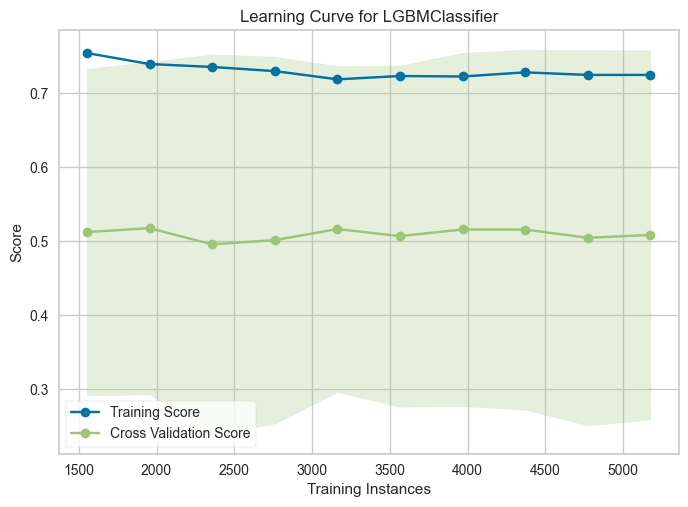

In [67]:
# 可視化　引数plot=learningで学習曲線
plot_model(tuned_lgbm, plot="learning")

# 2本の線の間隔（過学習チェック）
# Training Score（青）: 学習データでの予測精度。Cross Validation Score（緑）: 検証データでの予測精度。塗りつぶしは標準偏差。
# 間隔が狭まっているほど、過学習せずに未知データにも対応できてるという意味。

# 右端の方で緑線が横ばい（収束してる）ならば、今の特徴量のままだとデータを増やしても劇的な精度向上は見込めない（今の特徴量の組み合わせで到達できる限界点が見えてそう）を表す。この場合に今以上の精度を目指すなら、データ件数を増やす努力よりも、新しい特徴量を追加する方が得策っぽい。
# もし右端がまだグイグイ上に向かっていたら、もっとデータを集めてサインともいえる。

# どちらもスコアが低いのは学習不足かもなのでパラメータを増やす。trainだけ高いのは過学習気味なのでパラメータ数を減らすなど。

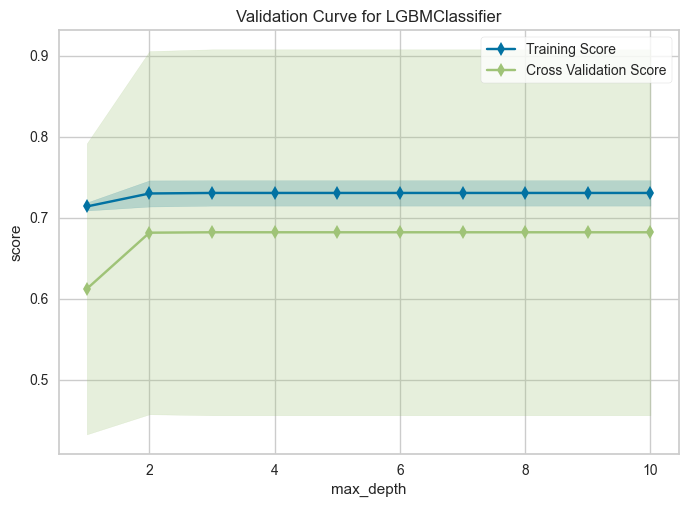

In [68]:
# 可視化　引数plot=vcで 検証曲線
plot_model(tuned_lgbm, plot="vc")

# 見た目はLearning Curveと似てるが目的が異なる。特定のハイパーパラメータ（max_depth）をいじると、scoreがどう変わるかを見ている。

# 1. max_depth（木の深さ）との関係
# 横軸のmax_depthは決定木の「階層をどこまで深くするか」を表してる。
# 左側（浅い）： 木が単純すぎて、複雑なパターンを捉えきれていない状態（未学習）。
# 右側（深い）： 木が複雑になり、細かいルールまで覚えようとしている状態。

# 2. 2本の線の重なり具合
# 青（学習用）と緑（検証用）がピッタリ重なって右肩上がりに進み、その後一緒に横ばいになっていれば、過学習してなさそう。
# もし過学習が起きてるなら、深くなるにつれて青だけが上がり続け、緑が下がっていく。

# 3. どこが最適かの判断
# max_depth=3くらいまでは急激に精度が上がっているけど、5以降はほとんどスコアが変わっていない。このモデルは深さ5くらいあれば十分で、それ以上に深くしても計算時間がかかるだけで意味がなさそう。

# Evaluation
- モデルの予測結果を評価し、解釈する
- モデルの性能を改善するためのハイパーパラメータチューニングや特徴量エンジニアリングを検討する

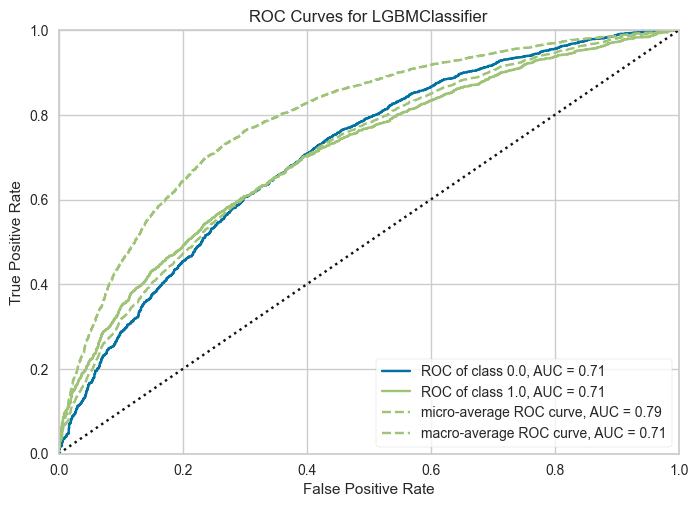

In [69]:
plot_model(tuned_lgbm, plot="auc")

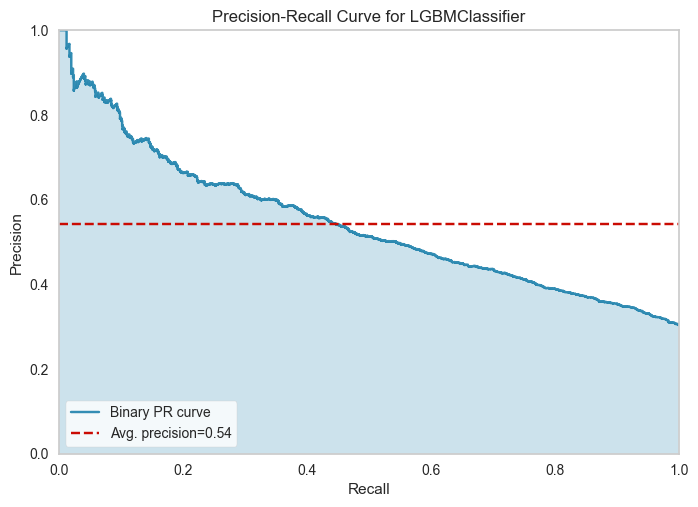

In [70]:
plot_model(tuned_lgbm, plot="pr")

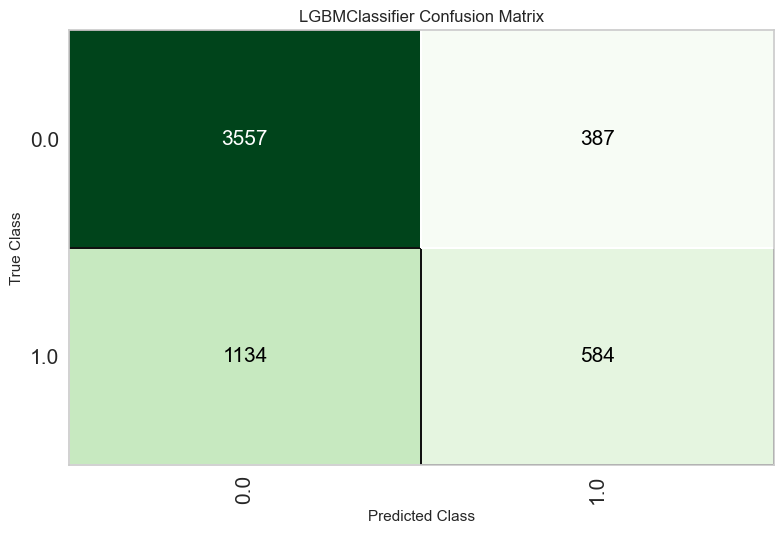

In [71]:
plot_model(tuned_lgbm, plot="confusion_matrix")

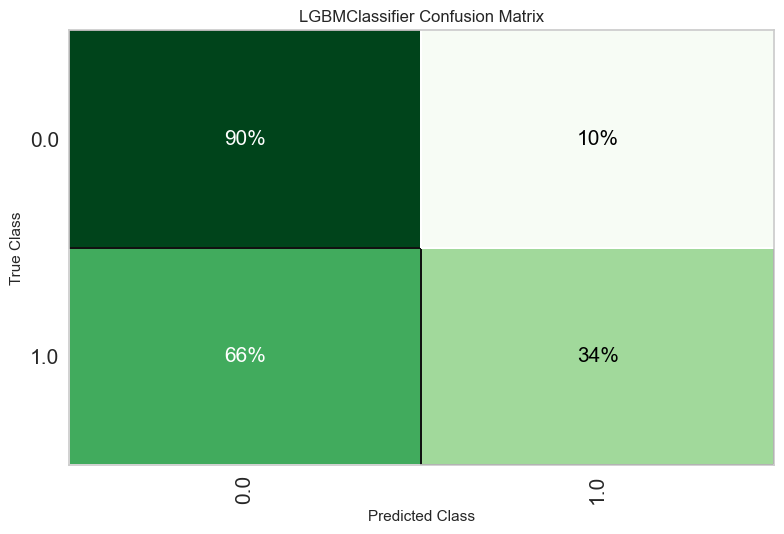

In [72]:
# Yellowbrickの引数設定
plot_model(tuned_lgbm, plot='confusion_matrix', plot_kwargs={'percent': True})

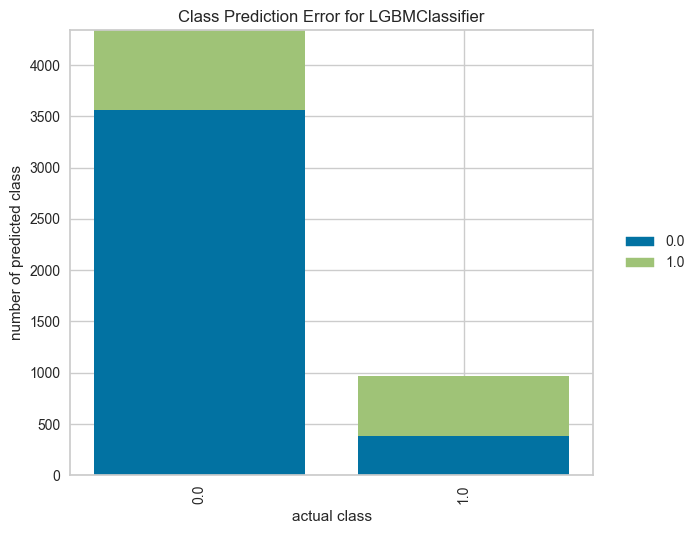

In [73]:
plot_model(tuned_lgbm, plot="error")
# 情報として混同行列と同じ。混同行列での色の濃さを高さで表現している。
# グラフの目盛はどうも大雑把らしいので混同行列の値とちょっとぐらい違っても気にしないでよい。

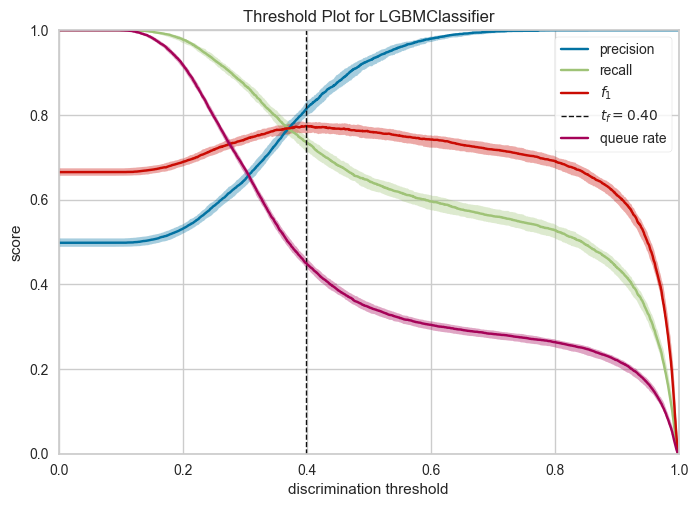

In [74]:
# thresholdを変えた時に、各指標がどう動くかを可視化
plot_model(tuned_lgbm, plot='threshold')

# 波線箇所（tf）: ハイパーパラメータ最適化時のoptimizeで指定した指標（F1値）が最大になるthreshold
# PrecisionとRecallを等価にみなすなら、2つが交差する位置のthresholdを採用する手もある。

# Queue Rate: thresholdを破線の値にしたときに、全データのうちhoge%を陽性（1）と判定して施策対象にできるとの意味。多すぎて対応しきれないなどの制約がある場合は、thresholdを右側にずらして対応件数を絞る判断の目安に。あるいはPrecisionやRecallのどちらを重視するかに応じて判断するのもあり。

In [75]:
# setupのtest_dataで指定したデータ（df_val）での予測結果を取得
tuned_lgbm.set_params(verbose=-1)
pred_holdout = predict_model(tuned_lgbm)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.7314,0.7100,0.3399,0.6014,0.4344,0.2756,0.2949


In [76]:
# prediction_scoreに格納されてる値は、そのラベルだと判定した確率
# なので、prediction_label=1ならprediction_scoreを、label=0なら1-prediction_scoreを格納したカラムを新設しておく
# 'pos_score' という名前で、1である確率を統一して格納する
pred_holdout['pos_score'] = pred_holdout.apply(
    lambda x: x['prediction_score'] if x['prediction_label'] == 1 else 1 - x['prediction_score'],
    axis=1
)

pred_holdout.head()

,membership_days,store_id,day_of_week_num,is_weekend,is_holiday,expanding_pv_sum,expanding_pv_count,expanding_visit_sum,expanding_purchase_sum,rolling_pv_sum_1d,...,diff_purchase_1to7d,diff_visit_rate_1to7d,diff_purchase_rate_1to7d,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase,is_purchased_within_3d,prediction_label,prediction_score,pos_score
22039,89.0,Store_A,6.0,1.0,0.0,53.0,36.0,4.0,1.0,NaN,...,NaN,-0.2,0.0,2.0,4.0,21.0,0.0,0,0.6601,0.3399
22040,187.0,Store_A,6.0,1.0,0.0,56.0,28.0,8.0,2.0,1.0,...,0.0,0.0,0.0,1.0,18.0,18.0,0.0,0,0.6216,0.3784
22041,33.0,Store_A,6.0,1.0,0.0,43.0,20.0,5.0,2.0,3.0,...,0.0,0.0,0.0,1.0,14.0,21.0,0.0,1,0.5340,0.5340
22042,864.0,Store_A,6.0,1.0,0.0,5.0,5.0,0.0,0.0,NaN,...,NaN,0.0,0.0,15.0,NaN,NaN,0.0,0,0.6396,0.3604
22043,4.0,Store_A,6.0,1.0,0.0,3.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,NaN,NaN,1.0,0,0.5997,0.4003


In [77]:
y_val = pred_holdout['is_purchased_within_3d'].values
y_pred_val = pred_holdout['pos_score'].values
y_class_pred = (y_pred_val > 0.5).astype(int)

In [78]:
# import
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# 検証データで予測確率を出す
# y_pred_val = model.predict_proba(X_val)[:, 1]


# モデル評価一覧出力の自作関数
def evaluate_model_performance(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    # 1. 各種スコア
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC : {average_precision_score(y_true, y_prob):.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred))
    # 2. 混同行列（Confusion Matrix）の表示
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title(f"Confusion Matrix \n(Threshold = {threshold})")
    # 3. 確率の分布
    axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.5, label='Actual: 0', color='blue')
    axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.5, label='Actual: 1', color='red')
    axes[1].set_title("Prediction Probability Distribution")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

 📊 MODEL PERFORMANCE SUMMARY 
[Validation Set]
ROC-AUC: 0.7100
PR-AUC : 0.5435
------------------------------
              precision    recall  f1-score   support

         0.0       0.76      0.90      0.82      3944
         1.0       0.60      0.34      0.43      1718

    accuracy                           0.73      5662
   macro avg       0.68      0.62      0.63      5662
weighted avg       0.71      0.73      0.71      5662



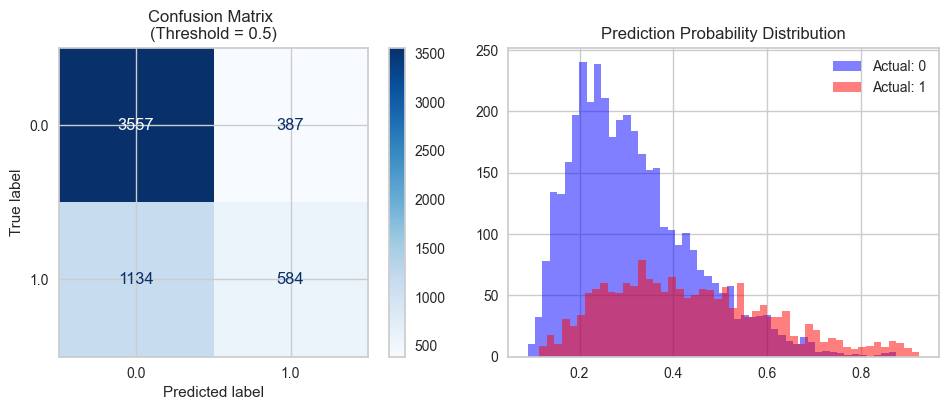

In [79]:
# モデルの識別性能、分類性能、予測確率の分布を見る
print(" 📊 MODEL PERFORMANCE SUMMARY ")
print(f"[Validation Set]")
evaluate_model_performance(y_val, y_pred_val, threshold=0.5)

# Prediction Probability Histogram: モデルが出した「1である確率（0.0〜1.0）」の分布。
# Actual=1の分布が1の側に寄り、Actual=0の分布が0の側に寄っている → 正例と負例をうまく区別できている。
# Actual=1とActual=0の分布の重なりが大きい → 両者を区別するのが難しく、現在の特徴量だけでは十分に分類できていない可能性がある。
# Actual=1の分布が0.5付近に集中している → 正例についてモデルが判断に迷っている。
# Actual=1の分布が0側に寄っている → 実際には正例なのに、モデルが負例と予測しやすい状態。Recallが低くなる原因になる。
# Actual=0の分布が1側に寄っている → 実際には負例なのに、モデルが正例と予測しやすい状態。Precisionが低くなる原因になる。
# なお分布だけで「確率そのものが正確」と判断することはできない。確率の信頼性を確認するには、Calibrationなど別の評価も必要。

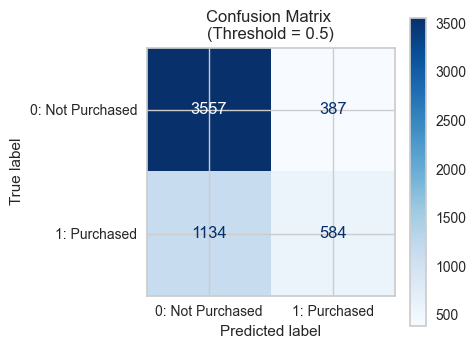

TN (True Negative): 3557
FP (False Positive): 387
FN (False Negative): 1134
TP (True Positive): 584
Total: 5662 (Actual=0: 3944, Actual=1: 1718, rate: 0.3034)
------------------------------
Accuracy: 0.731
Precision: 0.601
Recall: 0.340
F1-score: 0.434
MCC: 0.295
Balanced Accuracy: 0.621


In [80]:
# 混同行列単体とよく見る評価指標

# 1. 予測値をクラスラベルに変換する
# しきい値の値以上は1:購入すると予測したとみなし、未満は0:購入しないと予測したものとみなす、という意味
threshold = 0.5
y_pred = (y_pred_val > threshold).astype(int)

# 2. 混同行列（Confusion Matrix）の表示
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0: Not Purchased', '1: Purchased'])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix \n(Threshold = {threshold})')
plt.show()

# 混同行列から各値を取り出す
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()  # [0,0], [0,1], [1,0], [1,1] の順
print(f"TN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")
print("Total: {0:} (Actual=0: {2:}, Actual=1: {3:}, rate: {4:.4f})".format(tn + fp + fn + tp, threshold, tn + fp, fn + tp, (fn + tp) / (tn + fp + fn + tp)))
print("-" * 30)

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_val, y_pred)
balanced_accuracy = 1/2 * (tp/(tp+fn) + tn/(tn+fp))

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"Balanced Accuracy: {balanced_accuracy:.3f}")

In [81]:
# その他の指標
negative_predictive_value = tn / (tn + fn)
specificity = tn / (tn + fp)
fdr = 1 - precision
fpr = 1 - specificity
fnr = 1 - recall
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(y_val, y_pred)

print(f"NPV(Negative Predictive Value): {negative_predictive_value:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"FDR(False Discovery Rate): {fdr:.3f}")
print(f"FPR(False Positive Rate): {fpr:.3f}")
print(f"FNR(False Negative Rate): {fnr:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")

NPV(Negative Predictive Value): 0.758
Specificity: 0.902
FDR(False Discovery Rate): 0.399
FPR(False Positive Rate): 0.098
FNR(False Negative Rate): 0.660
Cohen's Kappa: 0.276


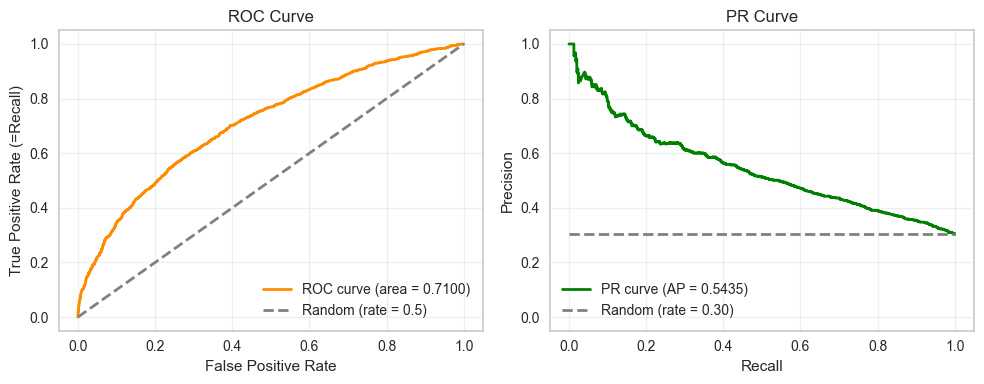

In [82]:
# ROC Curve, PR Curve

# 1. データの準備
fpr, tpr, _ = roc_curve(y_val, y_pred_val)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_val, y_pred_val)
pr_auc = average_precision_score(y_val, y_pred_val)

pos_rate = np.mean(y_val)   # 検証データにおける正例の出現率（PR Curveのランダム線用）

# プロット
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='dashed', label=f'Random (rate = 0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (=Recall)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# PR Curve
ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax2.plot([0, 1], [pos_rate, pos_rate], color='gray', lw=2, linestyle='dashed', label=f'Random (rate = {pos_rate:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('PR Curve')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

✨ Best F1-score: 0.5378 at Threshold: 0.3231


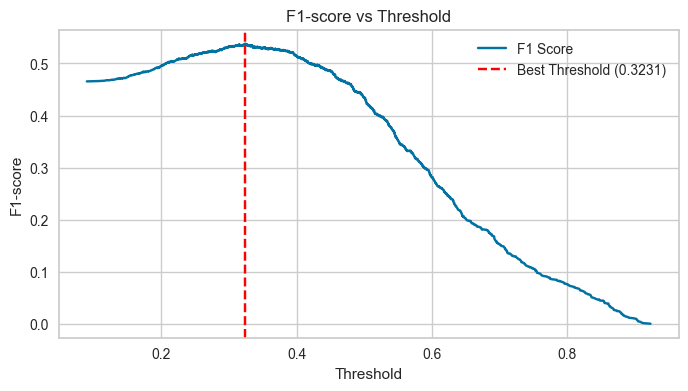

In [83]:
# F1-scoreを最大化するしきい値を求める（thresholdを変えるとF1-scoreがどう変化するかのプロット）
# モデルが固まった後に、目的に合わせて（F1-scoreでモデル評価するなら）、thresholdを調整する最終工程で用いる

# しきい値ごとのスコアを計算
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_val)
# thresholds: 予測確率をもとにした（ユニークにした）各thresholdの値が入っている → 基本的には異なる予測確率ごとに1つ
# precisions: それぞれのthresholdでPositiveと判定した場合のPrecisionが入っている → thresholds より1個多い
# recalls: それぞれのthresholdでPositiveと判定した場合のRecallが入っている → thresholds より1個多い
# 余分な最後の1個: precision = 1、recall = 0 → thresholdに対応する値ではないPR曲線の端点
# PR Curveのプロット時はthresholdsは使わないため、_を使って無視している

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"✨ Best F1-score: {best_f1:.4f} at Threshold: {best_threshold:.4f}")

# プロット
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='dashed', label=f'Best Threshold ({best_threshold:.4f})')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs Threshold')
plt.legend(loc='best')
plt.show()

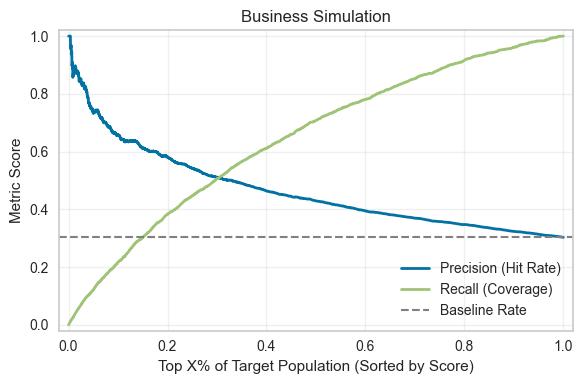

Top 10%: Precision=0.659, Recall=0.217
Top 20%: Precision=0.582, Recall=0.384
Top 30%: Precision=0.511, Recall=0.506
Top 40%: Precision=0.464, Recall=0.612
Top 50%: Precision=0.429, Recall=0.707
Top 60%: Precision=0.395, Recall=0.781
Top 70%: Precision=0.370, Recall=0.853
Top 80%: Precision=0.347, Recall=0.916
Top 90%: Precision=0.324, Recall=0.960


In [84]:
# 予測確率が上位〇%ごとの指標をプロットする
# 施策対象とする人たちの割合（予測確率の上位何%までとするか）を変えると、PrecisionとRecallがどう変わるかをみる意図。
# PrecisionとRecallがトレードオフになっていることを直感的に理解しやすい。
# 2本のグラフの交差点に意味はない。横軸の各値のときに、PrecisionとRecallがそれぞれどの程度かを確認することに意味がある。

precision_plot = precisions[:-1]
recall_plot = recalls[:-1]

# 各thresholds以上の予測確率を持つ人が、全体の（上位）何%にあたるかを計算
target_ratios = []
for t in thresholds:
    target_ratio = np.sum(y_pred_val >= t) / len(y_pred_val)
    target_ratios.append(target_ratio)

# プロット
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(target_ratios, precision_plot, lw=2, label='Precision (Hit Rate)')
ax.plot(target_ratios, recall_plot, lw=2, label='Recall (Coverage)')
ax.axhline(y=pos_rate, color='gray', lw=1.5, linestyle='dashed', label='Baseline Rate')
ax.set_xlabel('Top X% of Target Population (Sorted by Score)')
ax.set_ylabel('Metric Score')
ax.set_title('Business Simulation')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10%刻みでの指標を出力
target_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for target_pct in target_percentages:
    idx = np.argmin(np.abs(np.array(target_ratios) - target_pct))
    print(
        f"Top {target_pct:.0%}: "
        f"Precision={precision_plot[idx]:.3f}, "
        f"Recall={recall_plot[idx]:.3f}"
    )

In [85]:
# 予測確率をもとにEDAするなら、元のデータフレームに予測値をくっつけてしまう
df_val_result = df_val.copy()
df_val_result['predict_prob'] = y_pred_val

# 例えば予測確率が高い順に並べてみる
print(df_val_result[['customer_id', 'date', 'predict_prob']].sort_values('predict_prob', ascending=False).head())

      customer_id       date  predict_prob
28160    zb229sjk 2025-11-09        0.9231
24917    c1b14ug4 2025-11-02        0.9122
24516    1w92dtek 2025-11-02        0.9098
28450    kpmry6j3 2025-11-09        0.9085
27501    ew6nqs6a 2025-11-08        0.9049


In [86]:
y_pred_val

array([0.3399, 0.3784, 0.534 , ..., 0.4755, 0.4973, 0.6662])

# PFI
**特徴量の重要度を知る** （Permutation Feature Importance）
- 特徴量が、モデルの予測にどの程度「重要な役割を果たしたか」を表す指標。
- ある特徴量の値をシャッフル（してその特徴量が使いものにならない状態に）したときに、モデルの評価指標がどれだけ悪化するか、この悪化度合いを重要度とみなしている。
- 重要度の低い特徴量を削減する候補として検討したり、重要度の高い特徴量を後述の手法で重点的に確認したりするなど、モデルの改善や特徴量の見直しに役立つ。
- 特徴量の重要度がドメイン知識に沿っているかを確認することで、適切なモデルになっているかのチェックにもなる。

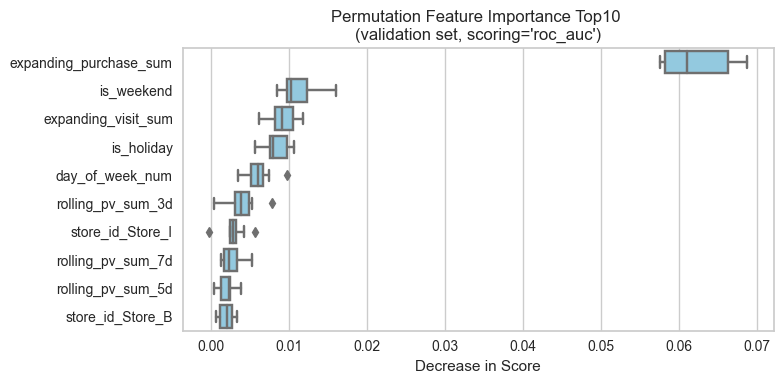

In [87]:
from sklearn.inspection import permutation_importance

# PyCaretの現在のホールドアウトデータ（検証データ）を取得
X_val = get_config('X_test_transformed')
y_val = get_config('y_test')

# PFIの計算（n_repeatsは試行回数。とりあえず5〜10くらいでOK）
result = permutation_importance(tuned_lgbm, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)

# 1. PFI結果をDataFrame化（列名が特徴量名、行が各試行）
df_pfi = pd.DataFrame(result.importances.T, columns=X_val.columns)

# 2. 平均値が高い順に並び替え
mean_importance = df_pfi.mean().sort_values(ascending=False)
df_pfi_sorted = df_pfi[mean_importance.index]

# 3. PFIのboxplot（top_n特徴量）
top_n = 10
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_pfi_sorted.iloc[:, :top_n], orient="h", color="skyblue")
plt.title(f"Permutation Feature Importance Top{top_n} \n(validation set, scoring='roc_auc')")
plt.xlabel("Decrease in Score")
plt.tight_layout()
plt.show()

In [88]:
# 検証データにおける、特徴量同士（数値型カラムのみ）の相関係数

# PFIは特徴量同士に強い相関がある場合、どちらの特徴量も重要度が低く出ることがある（重要度を過小評価してしまう）
# なので、特徴量同士の相関も確認しておくと、PFIの結果を解釈する際に役立つ
top_corr_df = get_top_correlations(X_val, threshold=0.7, top_n=20)
print(top_corr_df)

                   feature_1                 feature_2  correlation
0          rolling_pv_sum_5d         rolling_pv_sum_7d     0.949268
1          diff_pv_sum_1to5d         diff_pv_sum_1to7d     0.946254
2        rolling_purchase_3d  rolling_purchase_rate_3d     0.941149
3         diff_pv_mean_1to5d        diff_pv_mean_1to7d     0.928252
4         rolling_pv_mean_5d        rolling_pv_mean_7d     0.924521
5        rolling_purchase_5d  rolling_purchase_rate_5d     0.911009
6           diff_count_1to5d          diff_count_1to7d     0.902033
7          rolling_pv_sum_3d         rolling_pv_sum_5d     0.894111
8        rolling_purchase_7d  rolling_purchase_rate_7d     0.877911
9           rolling_visit_5d          rolling_visit_7d     0.871935
10       rolling_purchase_5d       rolling_purchase_7d     0.868906
11          diff_visit_1to5d          diff_visit_1to7d     0.866399
12         rolling_pv_sum_3d        rolling_pv_mean_3d     0.863105
13        rolling_pv_mean_3d        rolling_pv_m

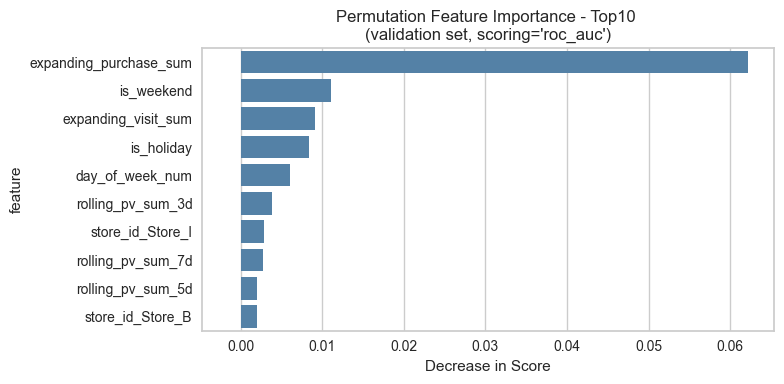

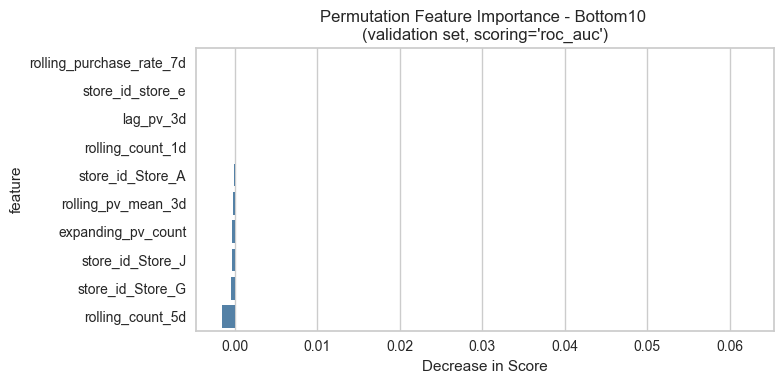

In [89]:
# PFIのmean, stdを算出（特徴量の重要度の平均と標準偏差）

# 1. 平均と標準偏差を DataFrame 化
df_pfi_summary = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# PFIのbarplot（特徴量の多少に応じて出力を変える）
top_n = 10
bottom_n = 10

# 上位と下位のグラフで同じx軸の範囲にするための設定
xmin = df_pfi_summary['importance_mean'].min()
xmax = df_pfi_summary['importance_mean'].max()
margin = (xmax - xmin) * 0.05
xmin = xmin - margin
xmax = xmax + margin

if len(df_pfi_summary) <= top_n + bottom_n:
    # 特徴量が少ない場合は全部表示
    plot_features = df_pfi_summary['feature']
    plt.figure(figsize=(8, max(4, len(plot_features) * 0.2)))
    sns.barplot(data=df_pfi_summary, x='importance_mean', y='feature', color='steelblue', errorbar='sd')
    plt.title("Permutation Feature Importance")
    plt.xlabel("Decrease in Score")
    plt.tight_layout()
    plt.show()

else:
    # 特徴量が多い場合は上位と下位に分ける
    top_features = df_pfi_summary.head(top_n)['feature']
    bottom_features = df_pfi_summary.tail(bottom_n)['feature']

    # 上位
    plt.figure(figsize=(8, max(4, top_n * 0.2)))
    sns.barplot(data=df_pfi_summary[df_pfi_summary['feature'].isin(top_features)], x='importance_mean', y='feature', color='steelblue', errorbar='sd')
    plt.title(f"Permutation Feature Importance - Top{top_n} \n(validation set, scoring='roc_auc')")
    plt.xlabel("Decrease in Score")
    plt.xlim(xmin, xmax)
    plt.tight_layout()
    plt.show()

    # 下位
    plt.figure(figsize=(8, max(4, bottom_n * 0.2)))
    sns.barplot(data=df_pfi_summary[df_pfi_summary['feature'].isin(bottom_features)], x='importance_mean', y='feature', color='steelblue', errorbar='sd')
    plt.title(f"Permutation Feature Importance - Bottom{bottom_n} \n(validation set, scoring='roc_auc')")
    plt.xlabel("Decrease in Score")
    plt.xlim(xmin, xmax)
    plt.tight_layout()
    plt.show()

## GPFI
Grouped Permutation Feature Importance

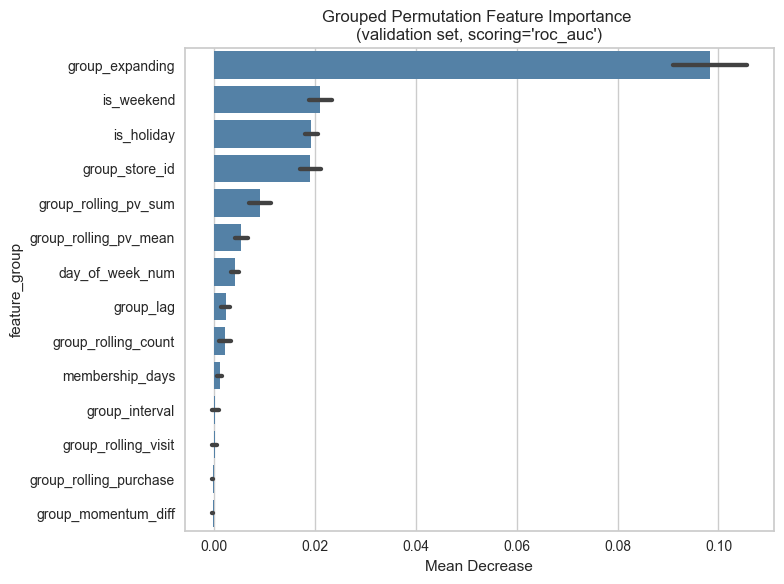

In [90]:
from collections import defaultdict

# 1. プレフィックスとドメインによる自動グループ化
feature_groups = defaultdict(list)

for col in X_val.columns:
    # Total（期間計）での累積集計値
    if col.startswith('expanding_'):
        feature_groups['group_expanding'].append(col)
    # State（状態）でのrolling系（ドメイン別に細分化）
    elif col.startswith('rolling_pv_sum_'):
        feature_groups['group_rolling_pv_sum'].append(col)
    elif col.startswith('rolling_pv_mean_'):
        feature_groups['group_rolling_pv_mean'].append(col)
    elif col.startswith('rolling_count_'):
        feature_groups['group_rolling_count'].append(col)
    elif col.startswith('rolling_visit_'):
        feature_groups['group_rolling_visit'].append(col)
    elif col.startswith('rolling_purchase_'):
        feature_groups['group_rolling_purchase'].append(col)
    # Lag（鮮度）直近の情報
    elif col.startswith('lag_'):
        feature_groups['group_lag'].append(col)
    # Momentum（勢い）変化の差分
    elif col.startswith('diff_'):
        feature_groups['group_momentum_diff'].append(col)
    # Momentum（勢い）変化の比率
    elif col.startswith('ratio_'):
        feature_groups['group_momentum_ratio'].append(col)
    # Interval（間隔）行動をしていない空白期間
    elif col.startswith('interval_'):
        feature_groups['group_interval'].append(col)
    # store_id（店舗ID）
    elif col.startswith('store_id'):
        feature_groups['group_store_id'].append(col)
    # その他のカテゴリ
    else:
        feature_groups[col].append(col) # 単体特徴量（store_id, day_of_week_num 等）

# 2. GPFIの計算
n_repeats = 10
baseline_score = roc_auc_score(y_val, tuned_lgbm.predict_proba(X_val)[:, 1])
gpfi_results = {group: [] for group in feature_groups}

for repeat in range(n_repeats):
    rng = np.random.default_rng(seed=42 + repeat)
    
    for group_name, cols in feature_groups.items():
        X_val_permuted = X_val.copy()
        shuffled_idx = rng.permutation(len(X_val_permuted))
        
        # 該当グループのカラムをデータ型（category型等）を維持したままシャッフル
        shuffled_df = X_val[cols].iloc[shuffled_idx]
        for col in cols:
            X_val_permuted[col] = shuffled_df[col].astype(X_val[col].dtype).values
        
        score_permuted = roc_auc_score(y_val, tuned_lgbm.predict_proba(X_val_permuted)[:, 1])
        gpfi_results[group_name].append(baseline_score - score_permuted)

# 3. 集計＆可視化
df_gpfi = pd.DataFrame(gpfi_results)
gpfi_mean_importance = df_gpfi.mean().sort_values(ascending=False)
df_gpfi_sorted = df_gpfi[gpfi_mean_importance.index]

plt.figure(figsize=(8, 6))
sns.barplot(data=df_gpfi_sorted.melt(var_name='feature_group', value_name='importance'), x='importance', y='feature_group', color='steelblue', errorbar='sd')
plt.title("Grouped Permutation Feature Importance \n(validation set, scoring='roc_auc')")
plt.xlabel("Mean Decrease")
plt.tight_layout()
plt.show()

# SHAP
**予測の理由を考える、理解する** （SHapley Additive exPlanations）
- 各特徴量が、予測にどれだけ影響を与えているか（寄与度）を表す指標。
- 平均的な予測値を出発点（ベースライン）として、各インスタンスの予測値がそこからどのように変化したかを、特徴量ごとに分解している（**寄与度を各特徴量に割り当てる**）。
- なので、インスタンスごとの寄与度合いだけでなく、これを集約することでモデル全体の傾向も把握できる。
- モデルがそのように予測した理由を説明したい、各特徴量が予測にどのように影響するかを理解したい場合に役立つ。

In [91]:
# SHAP値を計算するオブジェクト（Explainer）を作成
explainer = shap.TreeExplainer(tuned_lgbm, feature_perturbation="tree_path_dependent")
# TreeExplainerはデフォルトでは、ツリーモデルのraw outputを説明する。
# LightGBMのbinary classificationでは、このraw outputは基本的にlog-odds（logit）である。
# ここではmodel_outputを指定していないため、デフォルトのraw outputを説明している。
# 以上から、ここで計算されるSHAP値は、「各特徴量がモデルの予測log-oddsをどれだけ押し上げたり下げたりしたか」を表している。

# 検証データ全件のSHAP値を格納（SHAP waterfallに使う）
shap_values = explainer(X_val)

# 検証データをサンプリングしておいて、
X_val_sample = X_val.sample(n=1000, random_state=42)

# サンプルぶんのSHAP値を格納（モデルの全体傾向把握: SHAP bar, beeswarm, dependence plotに使う）
shap_values_sample = explainer(X_val_sample)
# shap_values_sample

## SHAP bar
各特徴量の予測値への平均的な寄与度を表す。
- SHAP値の絶対値の平均 Mean Absolute SHAP Value）: モデルの出力への平均的な影響度
- 並び順は寄与度の絶対値の平均値の大きさ順。その特徴量が予測値（サンプル事例の場合は購入する/しない）をどれだけ大きく動かしたか。
- 予測値にプラスに効くかマイナスに効くかはこのグラフではわからない。

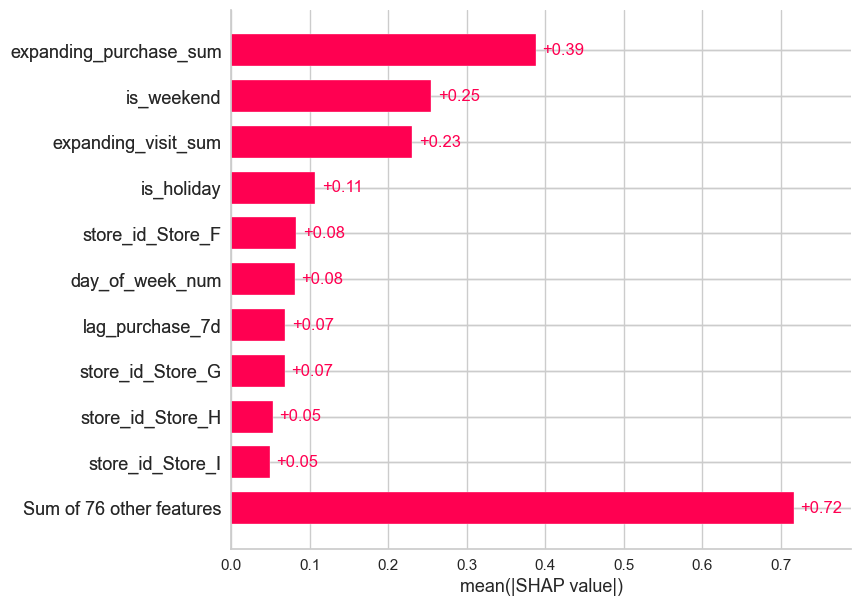

In [92]:
shap.plots.bar(shap_values_sample, max_display=11)

In [93]:
# 特徴量のカラム名と、SHAP値の絶対値の平均をデータフレームにする（PDPで使う）
mean_abs_shap = np.abs(shap_values_sample.values).mean(axis=0)

df_shap_importances = pd.DataFrame({
    'feature': X_val.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

# mean_abs_shap順でrankを付与
df_shap_importances['rank'] = range(1, len(df_shap_importances) + 1)

print(f'Number of features: {len(df_shap_importances)}')
# 上位10個を表示
print("📊 Mean Absolute SHAP (Top 10)")
print(df_shap_importances[['feature', 'mean_abs_shap', 'rank']].head(10).round(2))

Number of features: 86
📊 Mean Absolute SHAP (Top 10)
                   feature  mean_abs_shap  rank
27  expanding_purchase_sum           0.39     1
22              is_weekend           0.25     2
26     expanding_visit_sum           0.23     3
23              is_holiday           0.11     4
6         store_id_Store_F           0.08     5
21         day_of_week_num           0.08     6
61         lag_purchase_7d           0.07     7
7         store_id_Store_G           0.07     8
8         store_id_Store_H           0.05     9
9         store_id_Store_I           0.05    10


## SHAP beeswarm
各特徴量について、値が高い場合・低い場合に、予測がどちらの方向へ動きやすいか。また、その影響にどの程度ばらつきがあるか（SHAP値の分布）を表す。
- 予測値への寄与度の方向性: 0より右はベースラインから予測を押し上げ、左は押し下げている。
- 寄与度の大きさ: 色で表す。一般的な表示では、赤は特徴量の値が高い、青は低い。

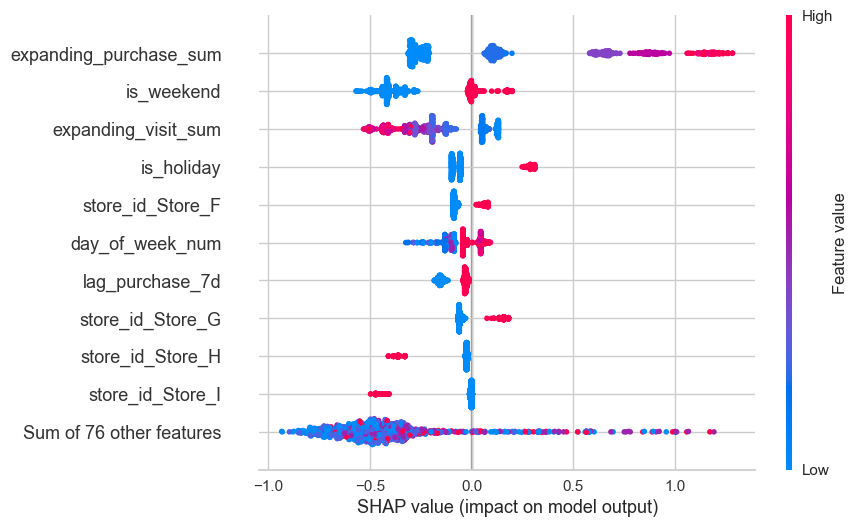

In [94]:
shap.plots.beeswarm(shap_values_sample, max_display=11)

## SHAP waterfall
ある顧客が「ラテを購入する確率が高い」と予測されたのは、どの特徴量が予測を押し上げ、どの特徴量が押し下げたのかを表す。
1. *E[f(X)]*: 学習済みの木から求められるモデル出力の期待値（予測確率をlogit変換した値）からスタートして、
1. 指定したインスタンスにおける各特徴量の寄与（赤や青のバー）を足し引きし、
1. サンプル事例の場合は「赤が長いほど買う確率を大きく上げ、青が長いほど下げる」と読む、
1. *f(x)*: 指定したインスタンスにおける最終的なモデル出力（予測確率をlogit変換した値）に到達する、という流れを表す。

*f(x)*=0とは予測確率0.5を意味する。ので、*f(x)* が正の値であれば購入確率は高そう、負の値であれば購入確率は低そう、と予測していることを表す。

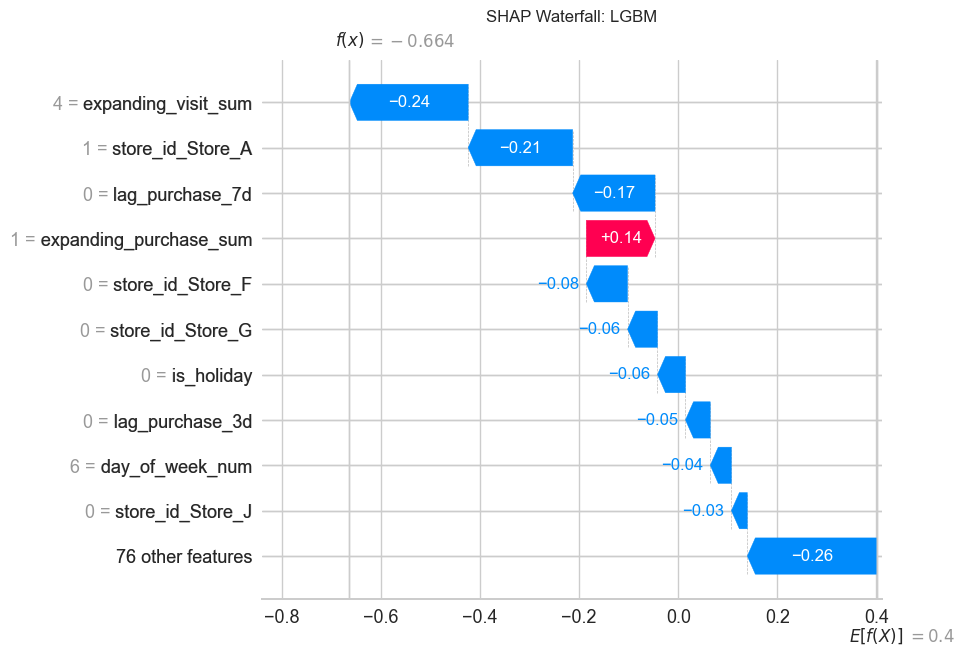

,original_index,date,customer_id,membership_days,store_id,is_purchased,day_of_week_num,is_weekend,is_holiday,expanding_pv_sum,...,diff_count_1to7d,diff_visit_1to7d,diff_purchase_1to7d,diff_visit_rate_1to7d,diff_purchase_rate_1to7d,interval_since_last_app_pv,interval_since_last_visit,interval_since_last_purchase,is_purchased_within_3d,predict_prob
0,24468,2025-11-02,3yph1lx2,89.0,Store_A,0.0,6.0,1.0,0.0,53.0,...,NaN,NaN,NaN,-0.2,0.0,2.0,4.0,21.0,0.0,0.3399


In [95]:
# 例えば、検証データに含まれる顧客IDなどを指定して、特定のインスタンスについてのSHAP waterfallを見たいとき用に、
# shap_valuesに対応するインデックスが欲しいので、検証データの元になったdataframeをreset_indexしたマッピングを用意する
df_val_result_map = df_val_result.reset_index(names="original_index")

# そして顧客IDなどを指定して、対応するshap_valuesのインデックスを取得する
# target_date = pd.Timestamp("2025-11-02")
# shap_index = df_val_result_map.query('customer_id=="pev2clzp" & date==@target_date').index[0]
# shap_index = df_val_result_map.query('original_index==24468').index[0]

# ここでは確実にコード実行できる条件指定にしている（検証データの先頭のインスタンスに対応するSHAP値のインデックスを取得）
shap_index = df_val_result_map.query("index==0").index[0] 

shap.plots.waterfall(shap_values[shap_index], max_display=11, show=False)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()

df_val_result_map.query("index==@shap_index")

In [96]:
# base_value = shap_values[shap_index].base_values
# base_prob = 1 / (1 + np.exp(-base_value))
# print(base_prob.round(4))
# # base_prob は、学習データに対する予測確率の平均に「近しい」値となる。 
# # base_prob ≒ model.predict_proba(X_train)[:, 1].mean()
# print((model.predict_proba(X_train)[:, 1].mean()).round(4))

# # 一方、指定したインスタンスの最終的なモデル出力 f(x) を確率に変換すると、モデルが出力した予測確率と一致する。
# f_x = shap_values[shap_index].base_values + shap_values[shap_index].values.sum()
# probability = 1 / (1 + np.exp(-f_x))
# print(probability.round(4))
# print(model.predict_proba(X_val)[:, 1][shap_index].round(4))

## SHAP Dependence Plot
特徴量の値とSHAP値の関係を散布図（scatter）で表す。
- 指定した特徴量について、横軸に特徴量の値、縦軸にSHAP値をプロットする。
- 後述のPDPが「特徴量の値を仮想的に変化させたときの予測値」を見るのに対し、SHAP Dependence Plotは「実際の観測値において、その特徴量が予測にどれだけ寄与したか」を散布図で見る。そして、個々のデータのバラツキが見える」ので、例えばある値を超えるとその特徴量の寄与がプラス側に大きく変わる、といった非線形な動きが見えやすい。
- 基本的にはもっとも交互作用の強い特徴量を探して色付けしてくれる。そのため、予期せぬ発見がある（設定やデータの素性次第では一番強いものが選ばれない場合があったり、直接指定もできる）。

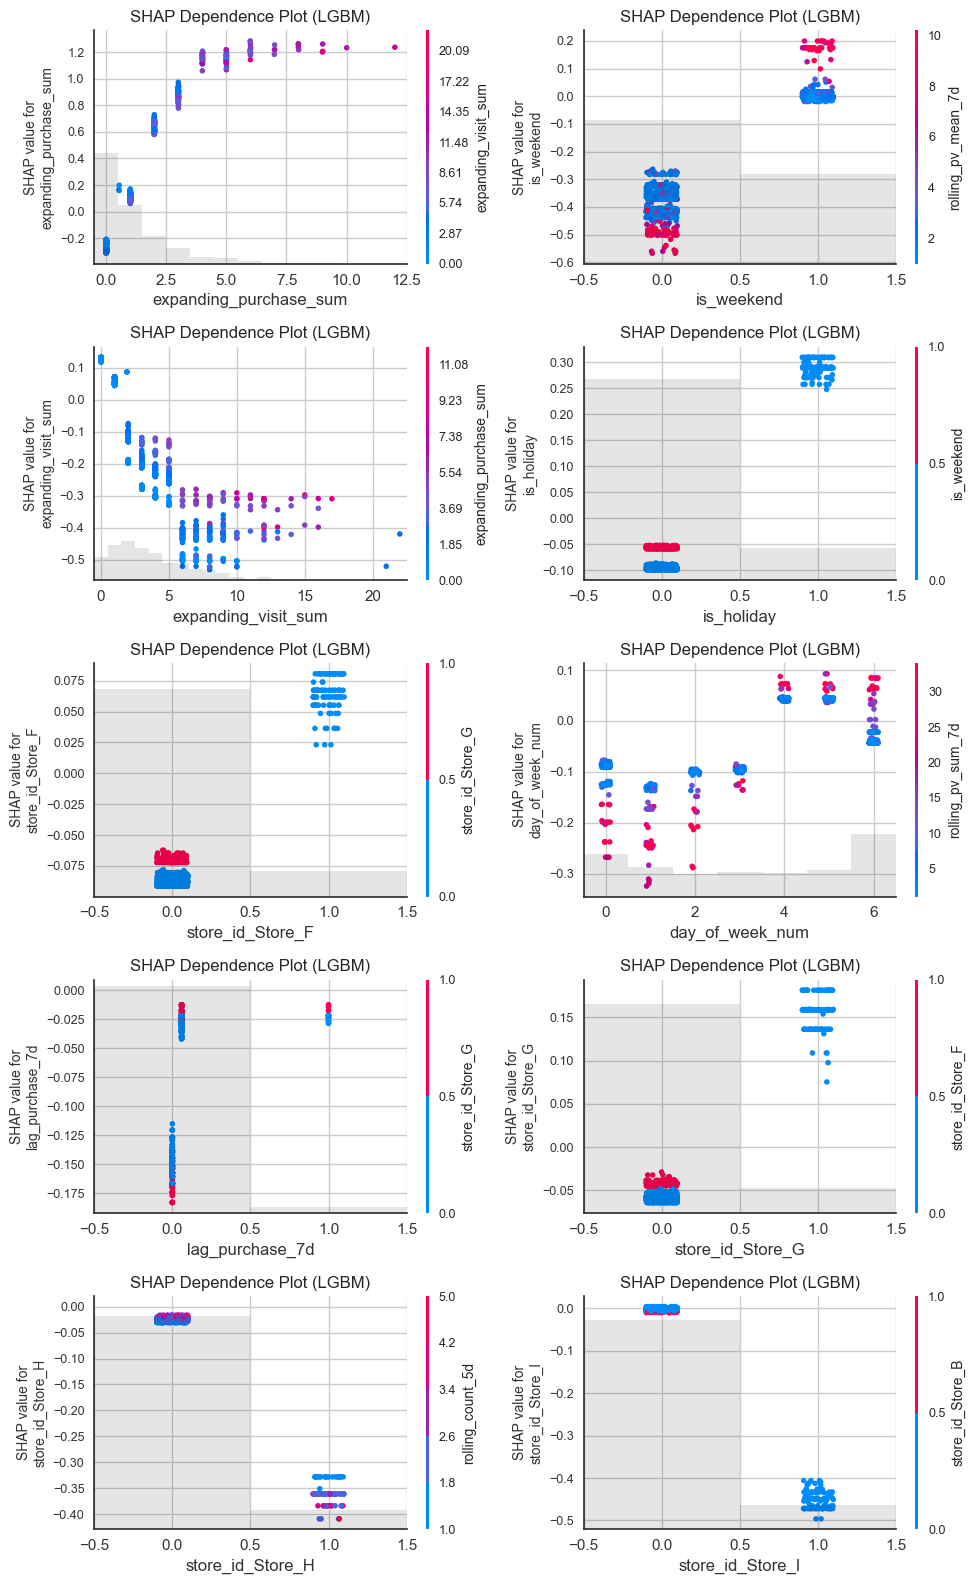

In [97]:
# SHAP barで表示された特徴量のうち、上位hoge個を一括プロットする
top_n = 10

# SHAP barの工程で準備しておいた df_shap_importances から、SHAP上位の特徴量名をリストで取得
top_features = df_shap_importances['feature'].head(top_n).tolist()

cols = 2
rows = (len(top_features) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 16))
axes = axes.flatten()

# フォントサイズの設定
FONT_SIZE_TITLE = 12   
FONT_SIZE_LABEL = 12   
FONT_SIZE_CBAR = 10    # カラーバー用は小さめに（大きいと右側のy軸ラベルと紛らわしいため）

# ここでは描画だけおこなう（カラーバーの操作はしない）
for i, feature in enumerate(top_features):
    ax_sub = axes[i]
    
    # 1. SHAP scatterを描画（colorを指定することで交互作用が描画される）
    shap.plots.scatter(
        shap_values_sample[:, feature], 
        color=shap_values_sample, 
        ax=ax_sub, 
        show=False  # まだ表示しない
    )
    
    # 2. タイトル、xlabel, ylabel のフォントサイズを設定
    ax_sub.set_title(f'SHAP Dependence Plot (LGBM)', fontsize=FONT_SIZE_TITLE)
    ax_sub.xaxis.label.set_size(FONT_SIZE_LABEL)
    ax_sub.yaxis.label.set_size(FONT_SIZE_LABEL)
    # ここに以前あった「if fig.axes: ...」のブロックは削除！

# 3. 余ったサブプロット枠を非表示（そのまま）
for j in range(len(top_features), len(axes)):
    fig.delaxes(axes[j])

# プロット後に一括でカラーバーの設定をおこなう
# fig.axes に登録されているすべての Axes を一つずつ確認する
for ax in fig.axes:
    # そのAxesの「ラベルオブジェクト（縦書きの変数名）」を直接取得する
    # SHAPが作成したカラーバーであれば、これでラベルを捕まえられる
    label = ax.yaxis.get_label()
    if label and label.get_text():
        ax.yaxis.label.set_size(FONT_SIZE_CBAR)  # カラーバーのラベルが存在すれば、フォントサイズを設定
        ax.tick_params(axis='y', labelsize=FONT_SIZE_CBAR - 1)  # ついでにカラーバーの目盛り（数値）も小さくする

fig.tight_layout()
plt.show()

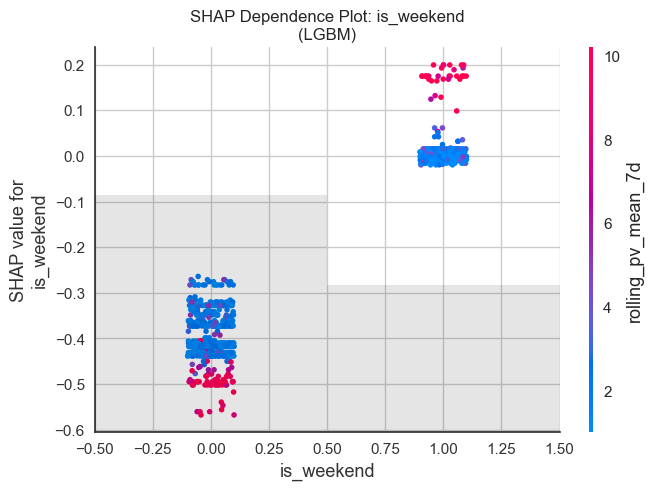

In [98]:
# 特定の特徴量を指定しての、SHAP Dependence Plot

# shap_target_feature = 'membership_days'
# ここでは確実にコード実行できる条件指定にしている（SHAP barで2位だった特徴量を指定）
shap_target_feature = df_shap_importances.query('rank == 2')['feature'].iloc[0]

shap.plots.scatter(shap_values_sample[:, shap_target_feature], color=shap_values_sample, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(LGBM)')
plt.show()

# PDP, ICE
**特徴量と予測値の関係を知る**
- 特定の特徴量の値を変化させたとき、予測がどう変わる（動く）かを表す指標。
    - PDP（Partial Dependence Plot）: 「平均的な」推移。
    - ICE（Individual Conditional Expectation）: 個人単位の反応曲線。
- 例えば「来店回数が一定以上になると、購入確率が急激に上昇する」といった非線形な関係が把握しやすい。
- 「hogeの値がfuga以上だと予測値（購入確率）が上がりやすそう」といった直感的な説明、具体的な提案に向いている。

In [99]:
# どの特徴量のPDPにするか指定（SHAP barの上位12個を指定）
target_features = df_shap_importances['feature'].head(12).tolist()

# print(f'Number of features: {len(df_shap_importances)}')
# # 上位10個を表示
# print("📊 Mean Absolute SHAP (Top 10)")
# print(df_shap_importances.head(10).round(2))

# カテゴリ変数など非数値型の特徴量をリストに（プロット時に指定することで棒グラフにしてくれる）
cat_features_list = [
    f for f in target_features 
    if X_val_sample[f].dtype == 'object' or hasattr(X_val_sample[f], 'cat') or isinstance(X_val_sample[f].iloc[0], str)
]

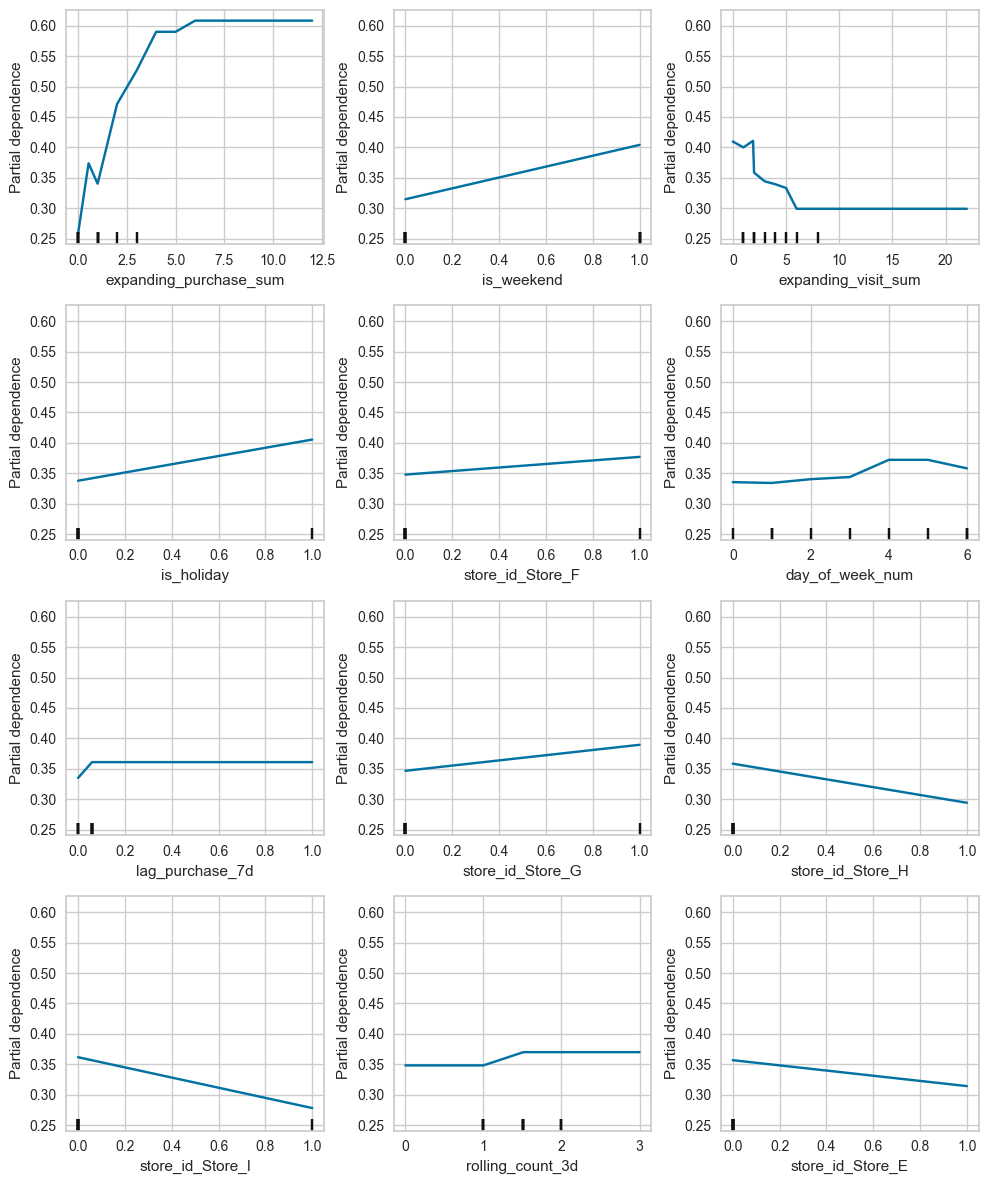

In [100]:
# PDP (average)

from sklearn.inspection import PartialDependenceDisplay

cols = 3
rows = (len(target_features) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 12))
axes = axes.flatten()  # 1次元の配列にして扱いやすくする
PartialDependenceDisplay.from_estimator(estimator=tuned_lgbm, X=X_val_sample, features=target_features, kind='average', ax=axes[:len(target_features)])
# 余った真っ白なサブプロット枠があれば非表示にする
for j in range(len(target_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

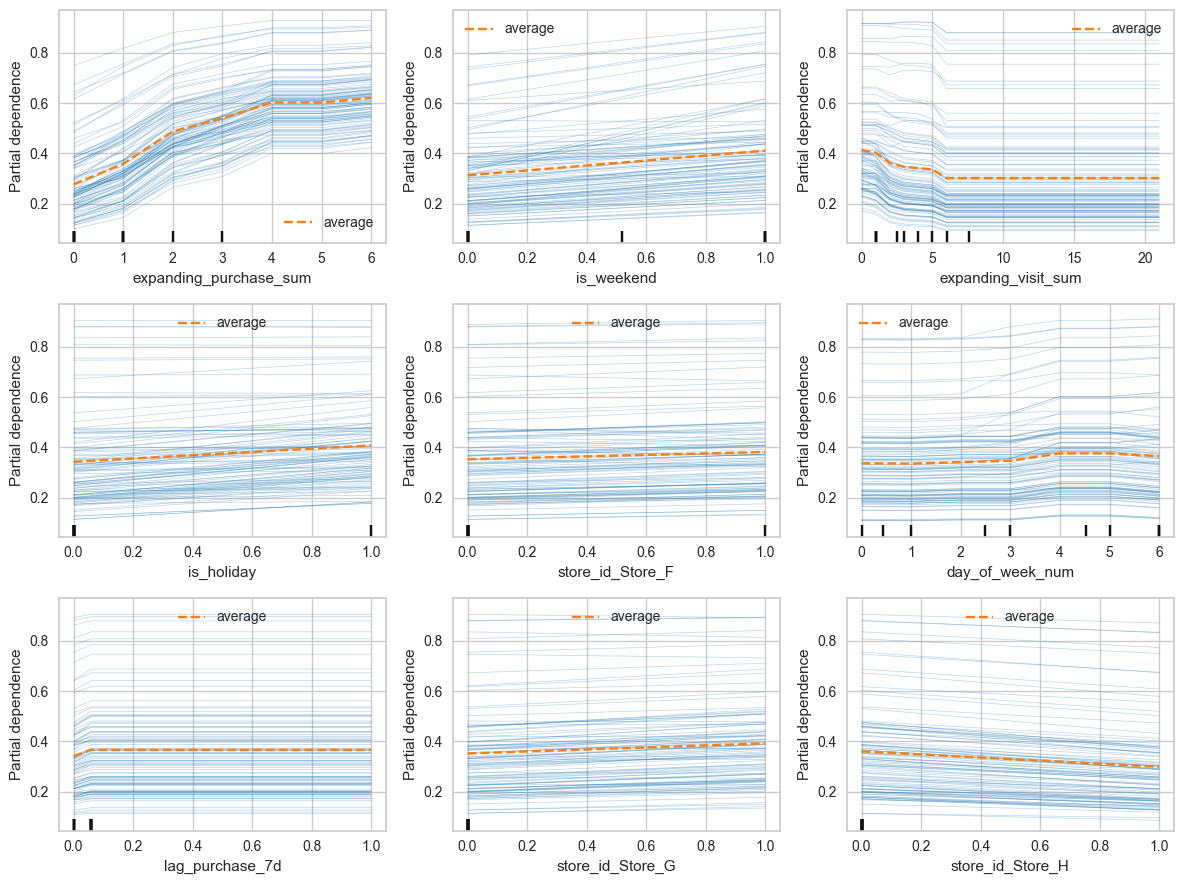

In [101]:
# ICE & PDP (both)

# bothの場合は特徴量を数値型に限定する必要ある
numeric_features = X_val.select_dtypes(include=['number']).columns.tolist()
# 数値型カラムだけで、SHAP値の上位9個を指定（averageよりも減らしてる）
target_features = (df_shap_importances[df_shap_importances['feature'].isin(numeric_features)]['feature'].head(9).tolist())

cols = 3
rows = (len(target_features) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.flatten()  # 1次元の配列にして扱いやすくする

# ICEを見やすくする意図でさらにサンプルを減らす
X_ice_plot_sample = X_val_sample.sample(n=100, random_state=42)
PartialDependenceDisplay.from_estimator(tuned_lgbm, X=X_ice_plot_sample, features=target_features, ax=axes[:len(target_features)], kind='both')
# 余った真っ白なサブプロット枠があれば非表示にする
for j in range(len(target_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()